# Financial Data Analytics

# Table of Contents

- [Data Preparation](#data-preparation)
  - [Stocks](#stocks)
  - [Crypto](#crypto)
  - [Meta Data](#meta-data)
  - [Conclusion on Data Quality](#conclusion-on-data-quality)

- [Data Analysis](#data-analysis)
  - [Historical Development](#historical-development)
  - [Value Change vs Share of Price Loss](#value-change-vs-share-of-price-loss)
    - [Stock Share with Loss/Gain](#stock-share-with-lossgain)
    - [Analysis of Actual Performance (Stocks)](#analysis-of-actual-performance-stocks)
    - [Crypto Share with Loss/Gain](#crypto-share-with-lossgain)
    - [Analysis of Actual Performance (Crypto)](#analysis-of-actual-performance-crypto)
    - [Structural Similarities between Crypto and Stocks](#structural-similarities-between-crypto-and-stocks)
  - [Correlation Analysis](#correlation-analysis)
  - [Savings Plan](#savings-plan)
  - [Statistical Distribution (Shapiro-Wilk)](#statistical-distribution-shapiro-wilk)
  - [Sharpe Ratio Calculation](#sharpe-ratio-calculation)
  - [Historical Market Events](#historical-market-events)

- [Model Building](#model-building)
  - [Training and Optimization](#training-and-optimization)
  - [Ex-Post](#ex-post)
  - [Autoregressive](#autoregressive)

- [Conclusion and Summary](#conclusion-and-summary)

- [Sources](#sources)



# Data Preperation

## Stocks

In [1]:
# Paths to data

data = "./data/"
stock_path = "./data/nasdaq-daily-stock-prices/"
crypto_path = "./data/crypto-currencies-daily-prices/"

Install required dependencies

In [2]:
!pip install pandas numpy folium geopandas matplotlib scikit-learn scipy yfinance seaborn plotly kaleido geopy geopandas pgeocode


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


Calculate stock splits for each ticker. Already calculated splits should ideally be ignored.

In [3]:
import numpy as np
import pandas as pd
import glob
import os


# preload stock splits
splits_df = pd.read_csv(data + "stock_splits_2000_2025.csv")

# Convert to datetime from timestamp to make comparison possible
splits_df["Date"] = pd.to_datetime(splits_df["Date"]).dt.strftime("%Y-%m-%d")

all_files = glob.glob(os.path.join(stock_path, "*.csv"))

fixed_files = []
df_list = []
all_stock_tickers = []
total_splits_corrected = 0

for file in all_files:
    # Get ticker from filename
    ticker_name = os.path.basename(file).split('.')[0]
    all_stock_tickers.append(ticker_name)
    df_temp = pd.read_csv(file)
    #Convert date column
    df_temp['date'] = pd.to_datetime(df_temp['date'])

    # Drop columns "high" and "low"
    df_temp = df_temp.drop(columns=["high", "low"])

    # Fill ticker from filename if necessary
    if df_temp["ticker"].isnull().any():
        df_temp["ticker"] = df_temp["ticker"].fillna(ticker_name)
        fixed_files.append(file)

    # Calculate stock splits
    ticker_splits = splits_df[splits_df['ticker'] == ticker_name].sort_values('Date', ascending=False)

    if not ticker_splits.empty:
        # Ensure correct sorting
        df_temp = df_temp.sort_values('date')
        
        for _, split in ticker_splits.iterrows():
            # Dates before split date
            mask_before = df_temp['date'] < split['Date']
            mask_at_split = df_temp['date'] >= split['Date']
            
            # Only continue if mask is given
            if mask_before.any() and mask_at_split.any():
                price_before = df_temp.loc[mask_before, 'close'].iat[-1]
                price_at_split = df_temp.loc[mask_at_split, 'open'].iat[0]
                
                observed_ratio = price_before / price_at_split
                split_ratio = float(split['Stock Splits'])

                # Check: Is split not yet priced in
                if abs(observed_ratio - split_ratio) < abs(observed_ratio - 1.0):
                    df_temp.loc[mask_before, ['open', 'close']] /= split_ratio
                    total_splits_corrected += 1

    df_list.append(df_temp)

# Merge all split data
df_after_splits = pd.concat(df_list, ignore_index=True)

print(f"Tickers corrected in: {fixed_files}")
print(f"{total_splits_corrected} splits were recalculated!")

Tickers corrected in: ['./data/nasdaq-daily-stock-prices/NA.csv']
518 splits were recalculated!


Compare the provided number of records with the records from the NASDAQ screener.

In [4]:

df_screener = pd.read_csv(data + "nasdaq_screener.csv")


print(df_screener["Symbol"].nunique())
print(df_after_splits["ticker"].nunique())


7022
3342


Conclusion: Significantly fewer records are available than are included in the screener. Most of the companies in the screener are therefore not relevant for us.

Now we check whether there are still missing values or tickers in the DataFrame.

In [5]:
# Check for any missing entries
df_na = df_after_splits[df_after_splits["ticker"].isna()].copy()
print(df_after_splits.isna().sum())
print(df_na)

ticker    0
date      0
open      0
close     0
dtype: int64
Empty DataFrame
Columns: [ticker, date, open, close]
Index: []


So there are no individual missing values within a row, but that does not mean that entire rows or, in the worst case, entire time periods are not missing.

We now examine the completeness of the data and the functionality of the back-calculation using a visual example.

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/3798797960.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_pot = yf.download(tickers=stock_ticker, start="2000-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


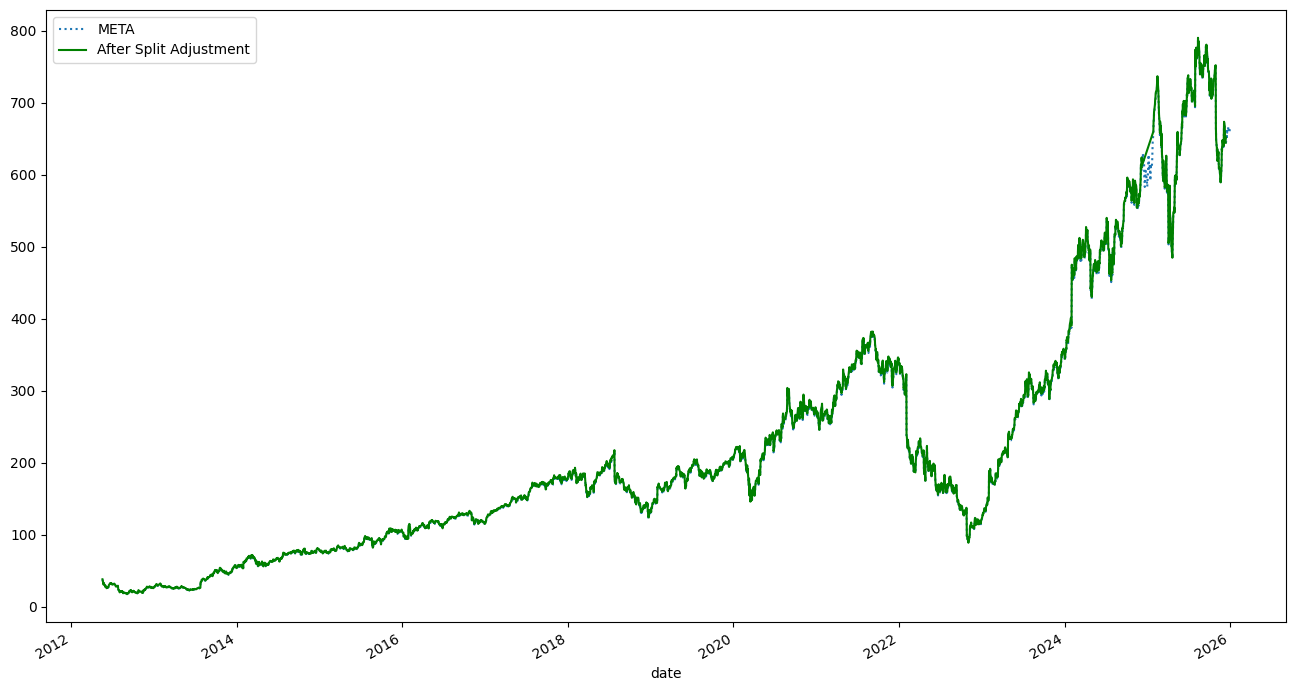

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stock_ticker = "META"

# Download Point of Truth from yfinance
stock_pot = yf.download(tickers=stock_ticker, start="2000-01-01", end="2025-12-31")

stock_split = df_after_splits[df_after_splits["ticker"]== stock_ticker].copy()

stock_split.reset_index(inplace=True, drop=True)

stock_split = stock_split.set_index("date")


stock_pot.index = pd.to_datetime(stock_pot.index).normalize()
stock_split.index = pd.to_datetime(stock_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

stock_pot.Close.plot(ax=ax, label="True Price Development", linestyle="dotted")
stock_split["close"].plot(ax=ax, label="After Split Adjustment", color="green")


ax.legend()

plt.show()

When testing different tickers, missing values often appear, especially at the end of 2024 and the beginning of 2025. These data must be downloaded from yfinance and added to our existing data. Missing data for every ticker => 2024-12-10 to 2025-01-25. For each ticker, the correlation with the yfinance data is calculated and used to decide whether it is usable. yfinance often returns incorrectly scaled data when a ticker's start date lies outside its own listing data. Unfortunately, this computation takes a very long time (approx. 17 min on MacBook Pro).

In [7]:
import time

# 2. Fill data gaps – process all stocks from the folder at once
start_gap = "2024-12-09"
end_gap = "2025-01-29"

MAX_DEVIATION = 0.25  # 25% threshold

all_frames = []

def chunk_list(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

# Process tickers in batches to avoid API limits
for i, ticker_chunk in enumerate(chunk_list(all_stock_tickers, 200)):
    print(f"Chunk {i+1}")

    ticker_str = " ".join(ticker_chunk)

    try:
        yf_data = yf.download(
            ticker_str,
            start=start_gap,
            end=end_gap,
            threads=True,
            auto_adjust=True,
            progress=False,
            group_by="ticker"
        )

        if yf_data.empty:
            continue

        for ticker in ticker_chunk:
            if ticker not in yf_data:
                continue

            # Get existing local data for the ticker
            own = df_after_splits[df_after_splits["ticker"] == ticker].copy()
            own["date"] = pd.to_datetime(own["date"])

            # Check if own data exists AFTER the gap
            if not (own["date"] > end_gap).any():
                print(f"SKIP {ticker}: No local data after end_gap")
                continue

            # Identify the last available data point BEFORE the gap
            own_before_gap = own[own["date"] < start_gap]

            if own_before_gap.empty:
                print(f"SKIP {ticker}: No local data before start_gap")
                continue

            last_own_row = own_before_gap.sort_values("date").iloc[-1]
            last_own_open = last_own_row["open"]
            
            # Extract and format Yahoo Finance data
            df_t = (
                yf_data[ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

            df_t["ticker"] = ticker
            df_t["date"] = pd.to_datetime(df_t["date"])
            df_t = df_t.sort_values("date")

            if df_t.empty:
                continue

            # Validate deviation of first YF price against last local price
            first_yf_open = df_t.iloc[0]["open"]
            deviation = abs(first_yf_open - last_own_open) / last_own_open

            if deviation > MAX_DEVIATION:
                print(
                    f"❌ SKIP {ticker}: Deviation {deviation:.2%} "
                    f"(own={last_own_open:.2f}, yf={first_yf_open:.2f})"
                )
                continue
                
            all_frames.append(df_t)

    except Exception as e:
        print(f"Chunk error: {e}")

    time.sleep(1) # Prevent rate limiting

# Combine all new data segments with the main dataset
if all_frames:
    yf_gap_data = pd.concat(all_frames, ignore_index=True)
    
    # 1. Concatenate existing data and new gap data
    df_combined = pd.concat([df_after_splits, yf_gap_data], ignore_index=True)
    
    # 2. Remove duplicates (preserve original data via keep='first')
    df_adjusted = df_combined.drop_duplicates(subset=['ticker', 'date'], keep='first')
    
    # 3. Sort once for final time-series alignment
    df_adjusted = df_adjusted.sort_values(['ticker', 'date']).reset_index(drop=True)

Chunk 1



25 Failed downloads:
['HTFL', 'BLIV', 'MGN', 'WSBK', 'DRDB', 'RDAG', 'OWLS', 'CEPT', 'CAEP', 'PHOE', 'SKBL', 'YMT', 'AHMA', 'NAVN', 'AGRZ', 'OTGA', 'MEHA', 'BCAR', 'ONCH', 'RYOJ']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['VBIX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29)')
['NUKK', 'ISPO', 'NITO', 'TZUP']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')


❌ SKIP WTO: Deviation 505972.87% (own=0.32, yf=1625.00)
❌ SKIP RADX: Deviation 51.34% (own=21.99, yf=10.70)
SKIP SKBL: No local data before start_gap
❌ SKIP FBLG: Deviation 1958.33% (own=2.40, yf=49.40)
SKIP RDAG: No local data before start_gap
❌ SKIP GGR: Deviation 1857.13% (own=0.61, yf=11.96)
❌ SKIP SKYQ: Deviation 691.49% (own=0.94, yf=7.44)
SKIP OWLS: No local data before start_gap
SKIP AHMA: No local data before start_gap
❌ SKIP NIVF: Deviation 1132.14% (own=112.00, yf=1380.00)
SKIP WHWK: No local data before start_gap
❌ SKIP BTAI: Deviation 1667.93% (own=0.40, yf=7.02)
SKIP CEPT: No local data before start_gap
SKIP OTGA: No local data before start_gap
SKIP DRDB: No local data before start_gap
SKIP HTFL: No local data before start_gap
SKIP RYOJ: No local data before start_gap
SKIP MGN: No local data before start_gap
SKIP MBAI: No local data before start_gap
SKIP NEUP: No local data before start_gap
SKIP SSII: No local data before start_gap
❌ SKIP PCSA: Deviation 2452.71% (own=1.0


19 Failed downloads:
['CARL', 'IPCX', 'LATA', 'FCHL', 'GPAC', 'CEPV', 'OMSE', 'PASW', 'SNDK', 'PLMK', 'EPWK', 'TACH', 'WXM', 'MAGH', 'KMTS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['ZEUS', 'EVOK', 'MNMD', 'PBBK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')


❌ SKIP GXAI: Deviation 82.91% (own=1.99, yf=3.64)
❌ SKIP TRNR: Deviation 866.17% (own=29.29, yf=283.00)
SKIP WXM: No local data before start_gap
SKIP BNKK: No local data before start_gap
SKIP DXST: No local data before start_gap
SKIP CAPS: No local data before start_gap
SKIP CARL: No local data before start_gap
❌ SKIP GOVX: Deviation 2780.34% (own=2.25, yf=64.75)
SKIP PLMK: No local data before start_gap
SKIP ALTS: No local data before start_gap
SKIP MAGH: No local data before start_gap
SKIP SNDK: No local data before start_gap
❌ SKIP SNEX: Deviation 34.04% (own=69.54, yf=45.87)
SKIP OMSE: No local data before start_gap
SKIP PASW: No local data before start_gap
SKIP LATA: No local data before start_gap
SKIP DOO: No local data before start_gap
SKIP TTAN: No local data before start_gap
❌ SKIP UK: Deviation 900.81% (own=1.23, yf=12.31)
SKIP ACFN: No local data before start_gap
SKIP IPCX: No local data before start_gap
SKIP VIVS: No local data before start_gap
SKIP FCHL: No local data befo

...

❌ SKIP RLYB: Deviation 752.83% (own=1.06, yf=9.04)
❌ SKIP DRIO: Deviation 1900.00% (own=0.76, yf=15.20)
❌ SKIP OST: Deviation 21986.03% (own=0.22, yf=47.75)
SKIP VELO: No local data before start_gap
SKIP IPOD: No local data before start_gap
SKIP BTTC: No local data before start_gap
❌ SKIP SXTC: Deviation 16163.20% (own=0.38, yf=61.80)
❌ SKIP INHD: Deviation 2290.10% (own=4.85, yf=115.92)
SKIP EXOZ: No local data before start_gap
SKIP SSEA: No local data before start_gap
SKIP THH: No local data before start_gap
❌ SKIP CHR: Deviation 16809.09% (own=2.75, yf=465.00)
SKIP CIGL: No local data before start_gap
❌ SKIP SCWO: Deviation 893.27% (own=0.97, yf=9.60)
SKIP RBNE: No local data before start_gap
SKIP LAWR: No local data before start_gap
SKIP AGH: No local data before start_gap
❌ SKIP MIGI: Deviation 2150.00% (own=1.20, yf=27.00)
❌ SKIP OM: Deviation 1363.71% (own=1.24, yf=18.15)
SKIP DYOR: No local data before start_gap
SKIP ABTC: No local data before start_gap
SKIP PLBL: No local data


28 Failed downloads:
['BPAC', 'OMDA', 'AXIN', 'CCII', 'GIW', 'FLY', 'ETOR', 'TDIC', 'ZGM', 'ATHR', 'MGRT', 'MB', 'PLTS', 'QSEA', 'TLIH', 'KFII', 'AARD', 'MWYN', 'CSAI', 'NPAC', 'AIRO', 'FIGR', 'CHYM']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['SGBX', 'AKRO', 'CREV', 'NAOV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')
['TBHC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29)')


❌ SKIP SXTP: Deviation 350.00% (own=5.60, yf=25.20)
❌ SKIP ZJK: Deviation 31.78% (own=10.70, yf=14.10)
SKIP MGRT: No local data before start_gap
❌ SKIP PSTV: Deviation 2400.00% (own=1.38, yf=34.50)
SKIP ATHR: No local data before start_gap
❌ SKIP CDT: Deviation 2343.61% (own=1117.20, yf=27300.00)
SKIP OMDA: No local data before start_gap
SKIP KFII: No local data before start_gap
SKIP TDIC: No local data before start_gap
SKIP AARD: No local data before start_gap
❌ SKIP SOWG: Deviation 1425.00% (own=3.00, yf=45.75)
SKIP ZGM: No local data before start_gap
SKIP MWYN: No local data before start_gap
SKIP NPAC: No local data before start_gap
SKIP ETOR: No local data before start_gap
❌ SKIP ADV: Deviation 2435.82% (own=3.49, yf=88.50)
❌ SKIP PSNY: Deviation 3039.18% (own=1.08, yf=33.90)
❌ SKIP ATPC: Deviation 4641.94% (own=1.55, yf=73.50)
❌ SKIP BJDX: Deviation 268.27% (own=4.16, yf=15.32)
❌ SKIP WORX: Deviation 1400.00% (own=1.84, yf=27.60)
SKIP FIGR: No local data before start_gap
SKIP GIW:


13 Failed downloads:
['GRAN', 'PLUT', 'KOYN', 'PARK', 'SOCA', 'SVCC', 'BACC', 'SZZL', 'HMR', 'WDAF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "Data doesn\'t exist for startDate = 1733720400, endDate = 1738126800")')
['LAZR', 'GBIO', 'FATBB']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-09 -> 2025-01-29) (Yahoo error = "No data found, symbol may be delisted")')


SKIP HMR: No local data before start_gap
SKIP PARK: No local data before start_gap
SKIP CEPO: No local data before start_gap
❌ SKIP VIVK: Deviation 19909.34% (own=1.45, yf=290.14)
❌ SKIP BDRX: Deviation 366.87% (own=51.51, yf=240.50)
❌ SKIP MKDW: Deviation 2677.43% (own=0.65, yf=17.97)
SKIP NEXM: No local data before start_gap
SKIP BACC: No local data before start_gap
❌ SKIP TOUR: Deviation 931.86% (own=1.03, yf=10.63)
SKIP STAI: No local data before start_gap
SKIP KOYN: No local data before start_gap
SKIP SOCA: No local data before start_gap
SKIP TONX: No local data before start_gap
SKIP SVCC: No local data before start_gap
SKIP JXG: No local data before start_gap
SKIP GRAN: No local data before start_gap
❌ SKIP DUO: Deviation 81.98% (own=8.88, yf=16.16)
SKIP WDAF: No local data before start_gap
SKIP FFAI: No local data before start_gap
❌ SKIP BTM: Deviation 631.28% (own=1.79, yf=13.09)
❌ SKIP JFBR: Deviation 1265.00% (own=54.40, yf=742.56)
SKIP NTCL: No local data before start_gap
SK

Only now is the restriction to data after 2000 applied. Before that, yfinance would have produced inconsistent data, since for some tickers the start date was outside their listing start date (if their IPO year was after 2000).

In [8]:
# startdate
millenium = pd.to_datetime('2000-01-01')
df_adjusted = df_adjusted[df_adjusted["date"] >= millenium].copy()

Check whether the data insertion worked (same ticker)

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/3000906008.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_pot = yf.download(tickers=stock_ticker, start=start_time, end=end_time)
[*********************100%***********************]  1 of 1 completed


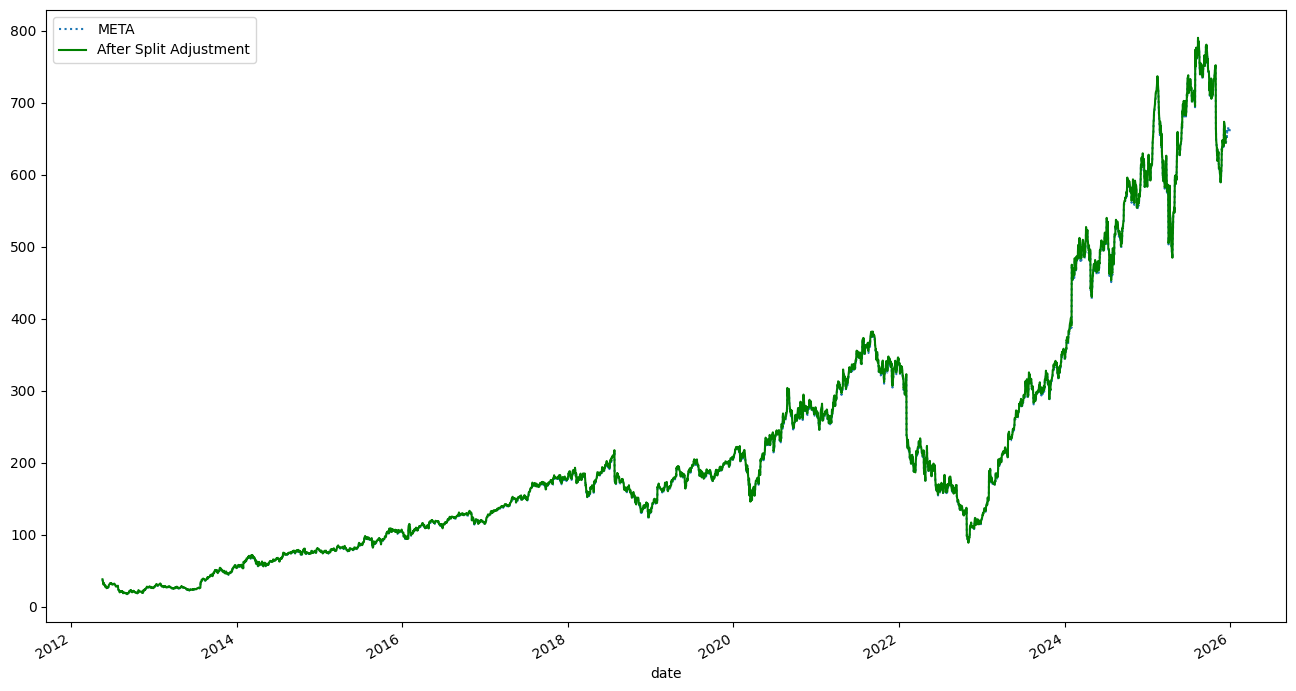

In [9]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stock_ticker = "META"

start_time="2000-01-01"
end_time="2025-12-31"

# Download Point of Truth from yfinance
stock_pot = yf.download(tickers=stock_ticker, start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

stock_split = df_adjusted[(df_adjusted["ticker"]== stock_ticker)].copy()

stock_split.reset_index(inplace=True, drop=True)

stock_split = stock_split.set_index("date")
#nvda = nvda.set_index("date")


stock_pot.index = pd.to_datetime(stock_pot.index).normalize()
stock_split.index = pd.to_datetime(stock_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

stock_pot.Close.plot(ax=ax, label="True Price Development", linestyle="dotted")
stock_split["close"].plot(ax=ax, label="After Split Adjustment", color="green")


ax.legend()

plt.show()

To gain some confidence in the values, data from 5 important sample companies are taken and compared to yfinance values using correlation (especially important are NASDAQ-100 stocks and not penny stocks). The goal is to achieve a correlation of more than 0.95, which represents an acceptable result and does not prevent us from working with the dataset. Marginal errors (from rounding, truncation, etc.) that occur in further analysis can be neglected!

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "NVDA", "MSFT", "AMZN", "CSCO"]
ticker_str = " ".join(tickers)

start_time = "2000-01-01"
end_time   = "2025-12-13"

# own data per ticker
own_data = {
    t: (
        df_adjusted[df_adjusted["ticker"] == t]
        .sort_values("date")["open"]
        .reset_index(drop=True)
    )
    for t in tickers
}

# download yfinance data
yf_data = yf.download(
    ticker_str,
    start=start_time,
    end=end_time,
    auto_adjust=False,
    progress=False,
    group_by="ticker"
)

# compute correlations
for t in tickers:
    if t not in yf_data:
        continue

    yf_open = yf_data[t]["Open"].reset_index(drop=True)

    # align series length
    n = min(len(yf_open), len(own_data[t]))

    corr = np.corrcoef(
        yf_open.iloc[:n],
        own_data[t].iloc[:n]
    )[0, 1]

    print(f"{t}: open price correlation = {corr:.5f}")


AAPL: open price correlation = 0.99991
NVDA: open price correlation = 1.00000
MSFT: open price correlation = 0.99992
AMZN: open price correlation = 1.00000
CSCO: open price correlation = 0.97816


Very high correlation of the provided data with the yfinance data. So the data largely agree with the yfinance data.

Aggregate the data per calendar week

In [11]:
# Ensure correct sorting
df_adjusted = df_adjusted.sort_values(['ticker', 'date'])


# Aggregate per Kalender Week starting on Mondays (freq="W_MON")
weekly_df = df_adjusted.groupby(['ticker', pd.Grouper(key='date', freq='W-MON')]).agg({
    'open': 'first',
    'close': 'last',
    
}).reset_index()

Save the DataFrames

In [12]:
df_adjusted.to_csv(data + "df_nasdaq_daily.csv", index=False)
weekly_df.to_csv(data + "df_nasdaq_weekly.csv", index=False)

## Crypto

Read in the data and remove the "high" and "low" columns.

In [13]:
import pandas as pd
import glob
import os
import numpy as np

# Get all filepaths ending with ".csv" in the crypto_path folder
all_files = glob.glob(os.path.join(crypto_path, "*.csv"))

print(all_files)

fixed_files = []
df_cry_list = []

for file in all_files:

    # Split the name from the file: "ADA.csv" -> "ADA"
    ticker_name = os.path.splitext(file)[0]
    df_temp = pd.read_csv(file)

    df_temp = df_temp.drop(columns=["high", "low"])

    if df_temp["ticker"].isnull().any():

        # Fill the missing entries with the filename
        df_temp["ticker"] = df_temp["ticker"].fillna(ticker_name)
        fixed_files.append(file)

    # append the read DateFrame to the list of DataFrames
    df_cry_list.append(df_temp)


# concat on the 0th axis, meaning there are rows being added
df_cry = pd.concat(df_cry_list, ignore_index=True)
df_cry = df_cry.drop(0)

df_cry["date"] = pd.to_datetime(df_cry["date"])

print(fixed_files)

['./data/crypto-currencies-daily-prices/HBAR.csv', './data/crypto-currencies-daily-prices/IOTA.csv', './data/crypto-currencies-daily-prices/KSM.csv', './data/crypto-currencies-daily-prices/SAND.csv', './data/crypto-currencies-daily-prices/CKB.csv', './data/crypto-currencies-daily-prices/MX.csv', './data/crypto-currencies-daily-prices/CRV.csv', './data/crypto-currencies-daily-prices/SUN.csv', './data/crypto-currencies-daily-prices/BCH.csv', './data/crypto-currencies-daily-prices/BTT.csv', './data/crypto-currencies-daily-prices/BTC.csv', './data/crypto-currencies-daily-prices/T.csv', './data/crypto-currencies-daily-prices/CHZ.csv', './data/crypto-currencies-daily-prices/TRX.csv', './data/crypto-currencies-daily-prices/BAT.csv', './data/crypto-currencies-daily-prices/SYRUP.csv', './data/crypto-currencies-daily-prices/HNT.csv', './data/crypto-currencies-daily-prices/RUNE.csv', './data/crypto-currencies-daily-prices/XRP.csv', './data/crypto-currencies-daily-prices/FTT.csv', './data/crypto-c

Check for missing data. Again, this does not say whether entire time series are missing.

In [14]:

print(df_cry.isna().sum())

ticker    0
date      0
open      0
close     0
dtype: int64


We now examine the completeness of the data and the functionality of the back-calculation using a visual example.

/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/1612197676.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)
[*********************100%***********************]  1 of 1 completed


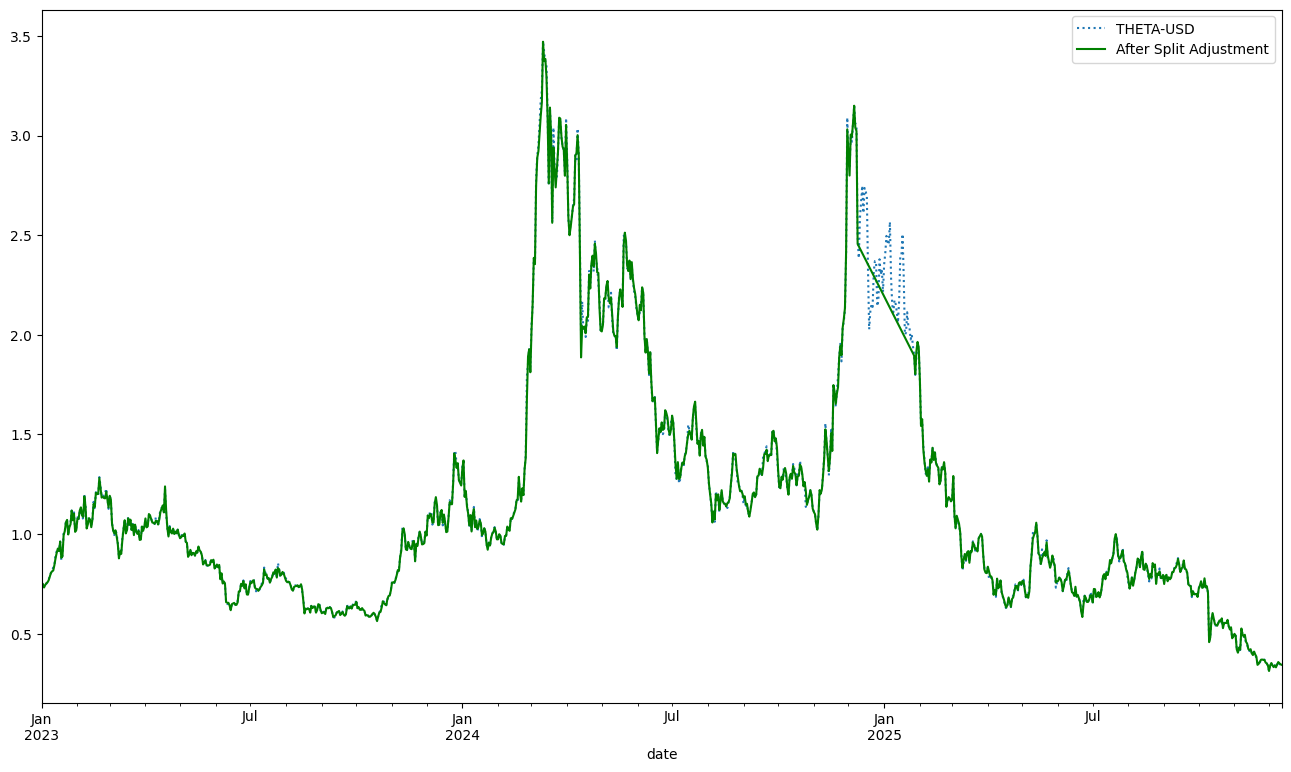

In [15]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

crypto_ticker = "THETA"
start_time = "2023-01-01"
end_time = "2025-12-12"

# Download Point of Truth from yfinance
crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

crypto_split = df_cry[(df_cry["ticker"]== crypto_ticker) & (df_cry["date"] > start_time) & (df_cry["date"] <= end_time)].copy()

crypto_split.reset_index(inplace=True, drop=True)

crypto_split = crypto_split.set_index("date")

crypto_split.head()

crypto_pot.index = pd.to_datetime(crypto_pot.index).normalize()
crypto_split.index = pd.to_datetime(crypto_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

crypto_pot.Close.plot(ax=ax, label="True Price Development", linestyle="dotted")
crypto_split["close"].plot(ax=ax, label="After Split Adjustment", color="green")


ax.legend()

plt.show()

When testing different tickers, missing values often appear, especially at the end of 2024 and the beginning of 2025. These data must be downloaded from yfinance and added to our existing data.

In [16]:
import time
import pandas as pd
import yfinance as yf

start_gap = pd.Timestamp("2024-12-01")
end_gap   = pd.Timestamp("2025-03-01")

MAX_DEVIATION = 0.30

all_frames = []

all_crypto_tickers = sorted(df_cry["ticker"].unique())

def chunk_list(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

# separate into chunks of 20
for i, ticker_chunk in enumerate(chunk_list(all_crypto_tickers, 53)):
    print(f"Chunk {i+1}")

    # add "-USD" for every crypto stock (that's how they are listed)
    ticker_yf = [x + "-USD" for x in ticker_chunk]
    ticker_str = " ".join(ticker_yf)

    try:
        yf_data = yf.download(
            ticker_str,
            start=start_gap,
            end=end_gap,
            auto_adjust=False,
            progress=False,
            threads=True,
            group_by="ticker"
        )

        if yf_data.empty:
            continue

        for yf_ticker in ticker_yf:
            ticker = yf_ticker.removesuffix("-USD")

            if yf_ticker not in yf_data:
                continue

            # get own data for ticker
            own = df_cry[df_cry["ticker"] == ticker].copy()
            own["date"] = pd.to_datetime(own["date"])

            # own data after gap?
            if not (own["date"] > end_gap).any():
                print(f"SKIP {ticker}: no own data after end_gap")
                continue

            # last trading day before start_gap
            own_before_gap = own[own["date"] < start_gap]

            if own_before_gap.empty:
                print(f"SKIP {ticker}: no own data before start_gap")
                continue

            last_own_row = own_before_gap.sort_values("date").iloc[-1]
            last_own_open = last_own_row["open"]

            # yfinance data
            df_t = (
                yf_data[yf_ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

            df_t["date"] = pd.to_datetime(df_t["date"])
            df_t["ticker"] = ticker

            df_t = df_t.sort_values("date")

            if df_t.empty:
                continue

            first_yf_open = df_t.iloc[0]["open"]

            # check deviation of own data and yfinance data
            deviation = abs(first_yf_open - last_own_open) / last_own_open

            # skip if deviation is too big
            if deviation > MAX_DEVIATION:
                print(
                    f"❌ SKIP {ticker}: deviation {deviation:.2%} "
                    f"(own={last_own_open:.2f}, yf={first_yf_open:.2f})"
                )
                continue

            df_t = df_t[
                (df_t["date"] >= start_gap) &
                (df_t["date"] <= end_gap)
            ]

            all_frames.append(df_t)

    except Exception as e:
        print(f"Chunk error: {e}")

    time.sleep(2)

# merge
if all_frames:
    yf_filtered = pd.concat(all_frames, ignore_index=True)

    df_idx = df_cry.set_index(["ticker", "date"])
    yf_idx = yf_filtered.set_index(["ticker", "date"])

    # only add missing data
    df_updated = df_idx.combine_first(yf_idx)

    df_cry = df_updated.reset_index()

Chunk 1



3 Failed downloads:
['IMX-USD', 'COMP-USD', 'GRT-USD']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-01 00:00:00 -> 2025-03-01 00:00:00)')


Chunk 2



3 Failed downloads:
['POL-USD', 'NFT-USD', 'SUPER-USD']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-01 00:00:00 -> 2025-03-01 00:00:00)')


❌ SKIP STX: deviation 99.82% (own=2.35, yf=0.00)
❌ SKIP SYRUP: deviation 98.98% (own=20.55, yf=0.21)
❌ SKIP UNI: deviation 100.00% (own=12.67, yf=0.00)
❌ SKIP XCN: deviation 55.17% (own=0.00, yf=0.00)


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/2979773629.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)
[*********************100%***********************]  1 of 1 completed


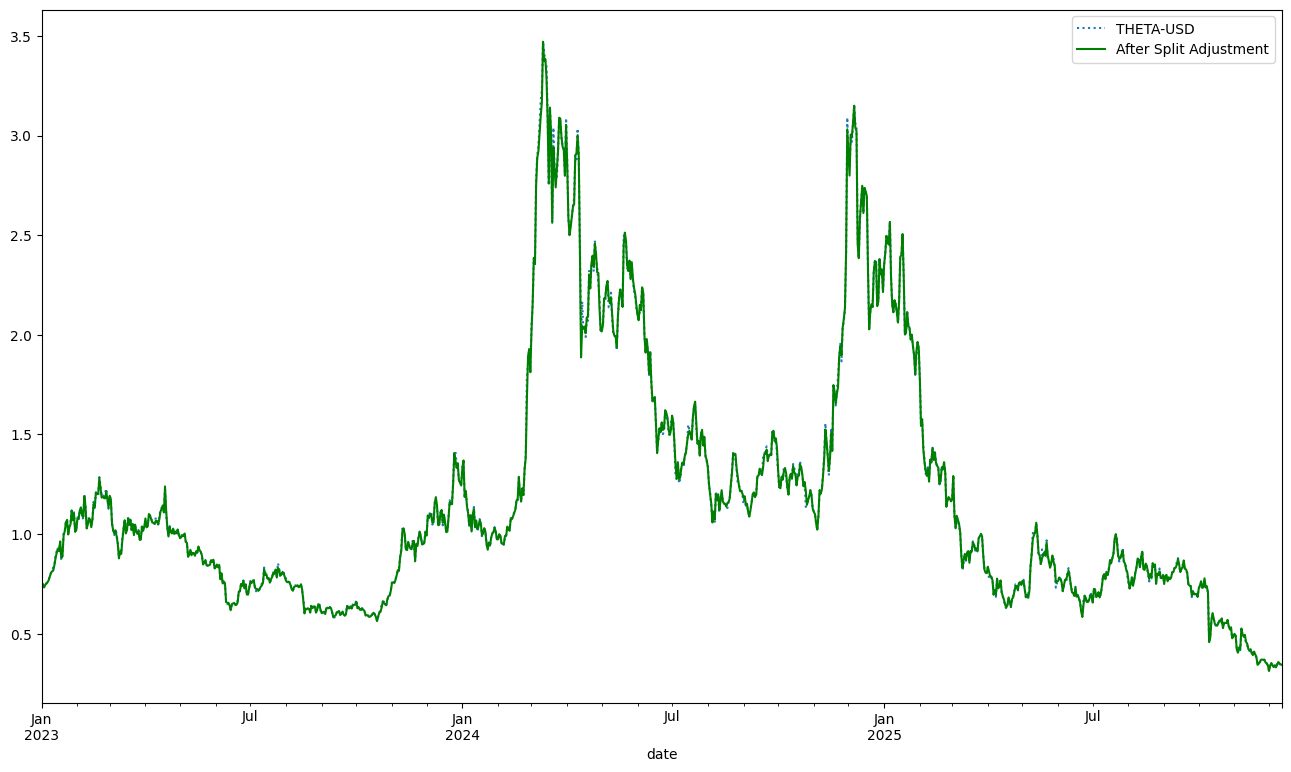

In [17]:
crypto_ticker = "THETA"

# Download Point of Truth from yfinance
crypto_pot = yf.download(tickers=crypto_ticker + "-USD", start=start_time, end=end_time)

start_time = pd.to_datetime(start_time)
end_time = pd.to_datetime(end_time)

crypto_split = df_cry[(df_cry["ticker"]== crypto_ticker) & (df_cry["date"] > start_time) & (df_cry["date"] <= end_time)].copy()

crypto_split.reset_index(inplace=True, drop=True)

crypto_split = crypto_split.set_index("date")

crypto_split.head()

crypto_pot.index = pd.to_datetime(crypto_pot.index).normalize()
crypto_split.index = pd.to_datetime(crypto_split.index).normalize()


fig, ax = plt.subplots(figsize=(16,9))

crypto_pot.Close.plot(ax=ax, label="True Price Development", linestyle="dotted")
crypto_split["close"].plot(ax=ax, label="After Split Adjustment", color="green")


ax.legend()

plt.show()

In [18]:
crypto_start = pd.to_datetime("2010-01-01")
df_cry = df_cry[df_cry["date"] >= crypto_start]


In [19]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["BTC", "ETH", "ADA", "XRP", "SOL", "SHIB", "DOGE"]
ticker_str = " ".join([t + "-USD" for t in tickers])

start_time = "2010-01-01"
end_time   = "2025-12-12"

# own data per ticker
own_data = {
    t: (
        df_cry[df_cry["ticker"] == t]
        .sort_values("date")["open"]
        .reset_index(drop=True)
    )
    for t in tickers
}

# download yfinance data
yf_data = yf.download(
    ticker_str,
    start=start_time,
    end=end_time,
    auto_adjust=False,
    progress=False,
    group_by="ticker"
)

# compute correlations
for t in tickers:
    yf_ticker = f"{t}-USD"
    if yf_ticker not in yf_data:
        continue

    own = (
        df_cry[df_cry["ticker"] == t]
        .set_index("date")["open"]
        .sort_index()
    )

    yf_open = yf_data[yf_ticker]["Open"].sort_index()

    # common dates
    common_dates = own.index.intersection(yf_open.index)

    if len(common_dates) < 10:
        print(f"{t}: not enough overlapping data")
        continue

    corr = own.loc[common_dates].corr(yf_open.loc[common_dates])

    print(f"{t}: open price correlation = {corr:.5f}")



BTC: open price correlation = 0.99997
ETH: open price correlation = 0.99988
ADA: open price correlation = 0.99978
XRP: open price correlation = 0.99930
SOL: open price correlation = 0.99988
SHIB: open price correlation = 0.99931
DOGE: open price correlation = 0.99961


Very good correlation of the values with the yfinance data. This is a good data foundation.

Aggregate the data into weekly prices

In [20]:
df_cry["date"] = pd.to_datetime(df_cry["date"])

# Ensure correct sorting
df_cry = df_cry.sort_values(['ticker', 'date'])

# Aggregate per Calender Week starting on Mondays (freq="W_MON")
weekly_df_cry = df_cry.groupby(['ticker', pd.Grouper(key='date', freq='W-MON')]).agg({
    'open': 'first',
    'close': 'last',
}).reset_index()


Save the crypto files

In [21]:
# safe as csv
df_cry.to_csv(data + "df_crypto_daily.csv", index=False)
weekly_df_cry.to_csv(data + "df_crypto_weekly.csv", index=False)


## Meta Data

Combine addresses and meta data to keep the information collected.

In [22]:
# get meta data and addresses
df_meta = pd.read_csv(data + "nasdaq_screener.csv")
df_addresses = pd.read_csv(data + "nasdaq_company_addresses.csv")

df_meta = df_meta.rename(columns={"Symbol": "Ticker"})

# combine the two DataFrames
df_combined = pd.merge(df_meta, df_addresses, on="Ticker", how="left")

In [23]:
df_combined.loc[df_combined["Ticker"].isna(), "Ticker"] = "NA" # Get the NA company and rename it to NA (Same error as in NASDAQ Data)
print(df_combined[df_combined["% Change"].isna()]) # Same company with no Marker Cap or any kind of value -> removal
df_combined = df_combined.dropna(subset=["% Change"])

print(df_combined.isna().sum())

     Ticker                                       Name Last Sale  Net Change  \
2697    GIW  GigCapital8 Corp. Class A Ordinary Shares     $9.93      9.9300   
2698  GIWWR                   GigCapital8 Corp. Rights   $0.4199      0.4199   

     % Change  Market Cap        Country  IPO Year   Volume Sector Industry  \
2697      NaN         0.0  United States    2025.0   265830    NaN      NaN   
2698      NaN         0.0  United States    2025.0  2328144    NaN      NaN   

             Address  
2697  Cayman Islands  
2698             NaN  
Ticker           0
Name             0
Last Sale        0
Net Change       0
% Change         0
Market Cap     396
Country        248
IPO Year      3039
Volume           0
Sector         670
Industry       671
Address       3805
dtype: int64


Very many missing entries for IPO years and addresses. But the important information (ticker, name, net change and volume) is fully present, which makes the analysis very feasible.

In [24]:
# Saving of the metadata DataFrame
df_combined.to_csv(data + "df_nasdaq_meta.csv", index=False)

### Conclusion on Data Quality

Stocks

The stock data is generally very complete, with almost no random missing entries for open or close prices. For the period from the end of 2024 to the beginning of 2025, however, whole rows are missing continuously and must be supplemented from external sources such as yfinance. Stock splits are partially already accounted for in the data; for other stocks they still need to be calculated. For older companies, small vertical shifts on the y-axis can be observed, probably due to rounding errors. Overall, most stock data is complete, especially after supplementing the missing periods via yfinance.

Cryptocurrencies

The cryptocurrency data is clearly more robust in terms of completeness: there are no random missing values. Here too, the same period from the end of 2024 to the beginning of 2025 is missing and could mostly be supplemented via yfinance. The data quality is overall high, since many time series are complete and appear plausible.

Metadata

There are significantly more gaps in the metadata. In particular, information like addresses and IPO years is often not available. However, the values important for analysis—especially ticker, name, and price data—could be cleaned. Missing sector information can slightly distort the analysis, but the impact remains manageable. IPO years are no longer reliable for the analysis given the large number of entries and therefore will not be considered in future evaluations.

Overall assessment

Inserting missing data and checking plausibility was time-consuming and error-prone. Especially for penny stocks, isolated inaccurate values may have been included, but this was largely avoided. Limitations arise partly from yfinance's automatic adjustment, especially when querying data for very old periods. Overall, the data quality can be described as solid, so the datasets can be used reliably for the planned analysis.

# Data Analysis

## Historical Development

In [25]:
import pandas as pd
import numpy as np

# Path to data
data = "./data/"
images = "./images/"

df_nasdaq_daily_pp = pd.read_csv(data + "df_nasdaq_daily.csv")
df_nasdaq_weekly_pp = pd.read_csv(data + "df_nasdaq_weekly.csv")
df_crypto_daily_pp = pd.read_csv(data + "df_crypto_daily.csv")
df_crypto_weekly_pp = pd.read_csv(data + "df_crypto_weekly.csv")
df_nasdaq_meta_pp = pd.read_csv(data + "df_nasdaq_meta.csv")

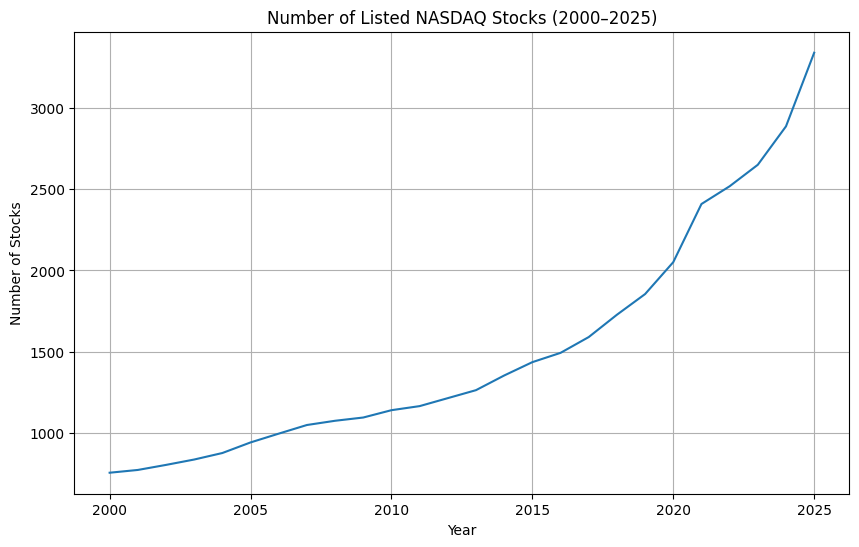

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# copy NASDAQ weekly df
prices_df = df_nasdaq_weekly_pp.copy()
prices_df["date"] = pd.to_datetime(prices_df["date"])

prices_df["year"] = prices_df["date"].dt.year

# aggregate unique ticker per year
listed_per_year = (
    prices_df
    .groupby("year")["ticker"]
    .nunique()
    .reset_index(name="n_listed")
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(listed_per_year["year"], listed_per_year["n_listed"])
plt.title("Number of Listed NASDAQ Stocks (2000–2025)")
plt.ylabel("Number of Stocks")
plt.xlabel("Year")
plt.grid(True)
plt.savefig(images + "amount_listed_nasdaq_stocks.png")
plt.show()


This representation is very misleading because historical companies that were delisted before 2025 are no longer shown. This means that in 2000 only the companies that existed at that time are shown. Nevertheless, the representation is quite interesting, because you can see a clear flattening of the rise in 2008, which of course is due to market uncertainty. The same phenomenon appears again in 2021, which slightly slows the rapid rise from previous years.

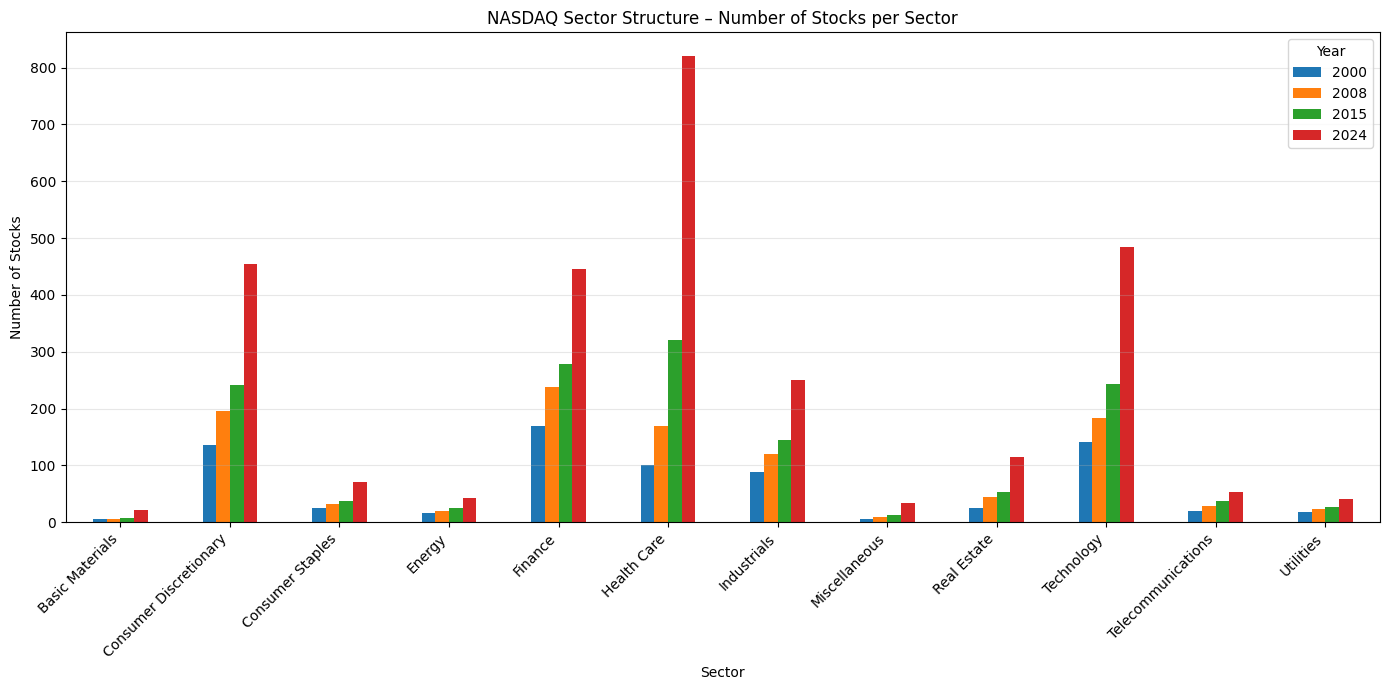

In [27]:
meta_df = df_nasdaq_meta_pp.copy()

# Merge meta on NASDAQ prices
df = prices_df.merge(
    meta_df[["Ticker", "Sector", "Industry"]],
    left_on="ticker",
    right_on="Ticker",
    how="left"
)

# aggregate unique ticker per year and sector
sector_year = (
    df.groupby(["year", "Sector"])["ticker"]
      .nunique()
      .reset_index(name="n_stocks")
)

# total amount per year
total_year = (
    df.groupby("year")["ticker"]
      .nunique()
      .reset_index(name="total")
)

# merge total amount on amount per ticker and year
sector_year = sector_year.merge(total_year, on="year")
sector_year["share"] = sector_year["n_stocks"] / sector_year["total"]

# only plot sample years
years_to_plot = [2000, 2008, 2015, 2024]

bar_data = sector_year[sector_year["year"].isin(years_to_plot)]

# plot
pivot_counts = bar_data.pivot(
    index="Sector",
    columns="year",
    values="n_stocks"
).fillna(0)

pivot_counts.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("NASDAQ Sector Structure – Number of Stocks per Sector")
plt.ylabel("Number of Stocks")
plt.xlabel("Sector")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(images + "nasdaq_sector_composition.png")
plt.show()

Here you can see how unevenly the NASDAQ is structured. It was expected that technology and finance would make up a large part of the index, but also consumer discretionary and especially healthcare are very dominant. Healthcare in particular has grown significantly in recent years. Again, one must keep in mind that only currently listed companies are part of this representation. It is surprising that telecommunications and energy make up such a small share of the index, even though both sectors are also associated with technology.

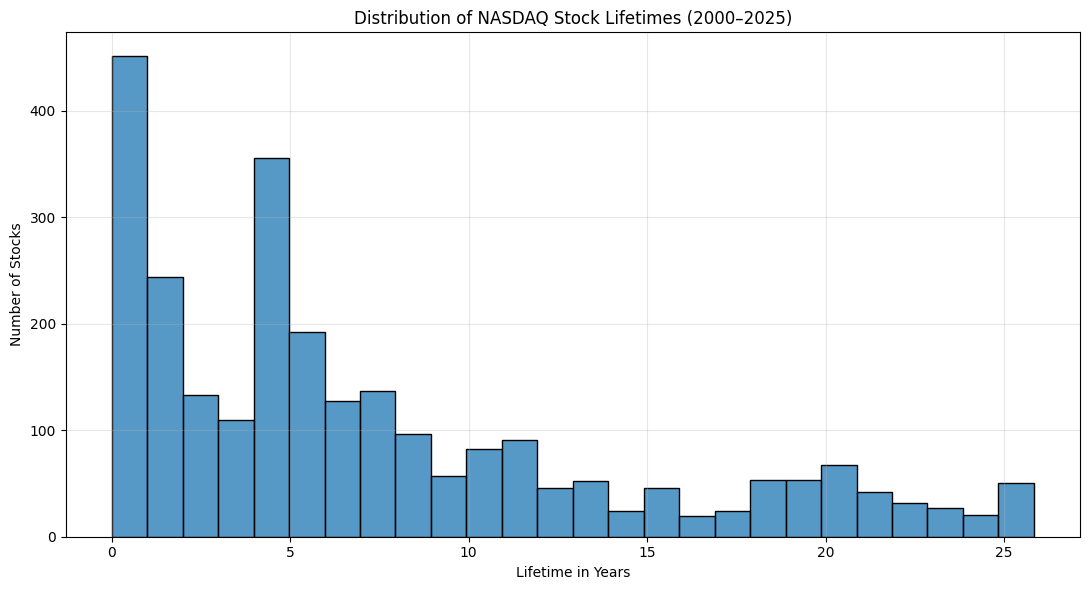

In [28]:
# aggregate minimum and maximum date entries
lifetimes = (
    prices_df.groupby("ticker")["date"]
    .agg(["min", "max"])
    .reset_index()
)
# calculate lifetime in days and years
lifetimes["lifetime_days"] = (lifetimes["max"] - lifetimes["min"]).dt.days
lifetimes["lifetime_years"] = lifetimes["lifetime_days"] / 365.25

#calculate median and average years
mean_lifetime = lifetimes["lifetime_years"].mean()
median_lifetime = lifetimes["lifetime_years"].median()

# merge metadata with lifetimes df
lifetimes = lifetimes.merge(
    meta_df[["Ticker", "IPO Year", "Sector"]],
    left_on="ticker",
    right_on="Ticker",
    how="left"
)

# aggregate the lifetime of the companies per year
ipo_survival = (
    lifetimes.groupby("IPO Year")["lifetime_years"]
    .mean()
    .reset_index()
)

ipo_survival = ipo_survival[ipo_survival["IPO Year"] >= 1990]

# aggregate lifetime for each sector
sector_survival = (
    lifetimes.groupby("Sector")["lifetime_years"]
    .mean()
    .sort_values(ascending=False)
)

summary = {
    "Avg lifetime (years)": mean_lifetime,
    "Median lifetime (years)": median_lifetime,
    "Total distinct stocks": lifetimes.shape[0],
    "Max listed in one year": listed_per_year["n_listed"].max(),
    "Min listed in one year": listed_per_year["n_listed"].min()
}

# only use time from 2000 (IPO could have happened earlier)
lifetimes = lifetimes[lifetimes["lifetime_years"] < 25.9].copy()

plt.figure(figsize=(11,6))

# Histogram
sns.histplot(
    data=lifetimes,
    x="lifetime_years",
    bins=26
)

plt.xlabel("Lifetime in Years")
plt.ylabel("Number of Stocks")
plt.title("Distribution of NASDAQ Stock Lifetimes (2000–2025)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(images + "lifetime_nasdaq-stocks.png")
plt.show()

In this representation you can very clearly see the market cycles of the US market. 25 years ago the economy recovered from the dot-com bubble, which led to a low number of new companies in the technology sector. Over the years there was an economic upswing until 2008 when the Great Financial Crisis began with the collapse of Lehman Brothers. Until 2021 there was again a period of economic growth, which peaked in 2020 with the COVID-19 pandemic. After a very poor market year in 2022, we are now in a period in which many startups, especially in the AI area, are founded, leading to over 400 new listings in the past year.

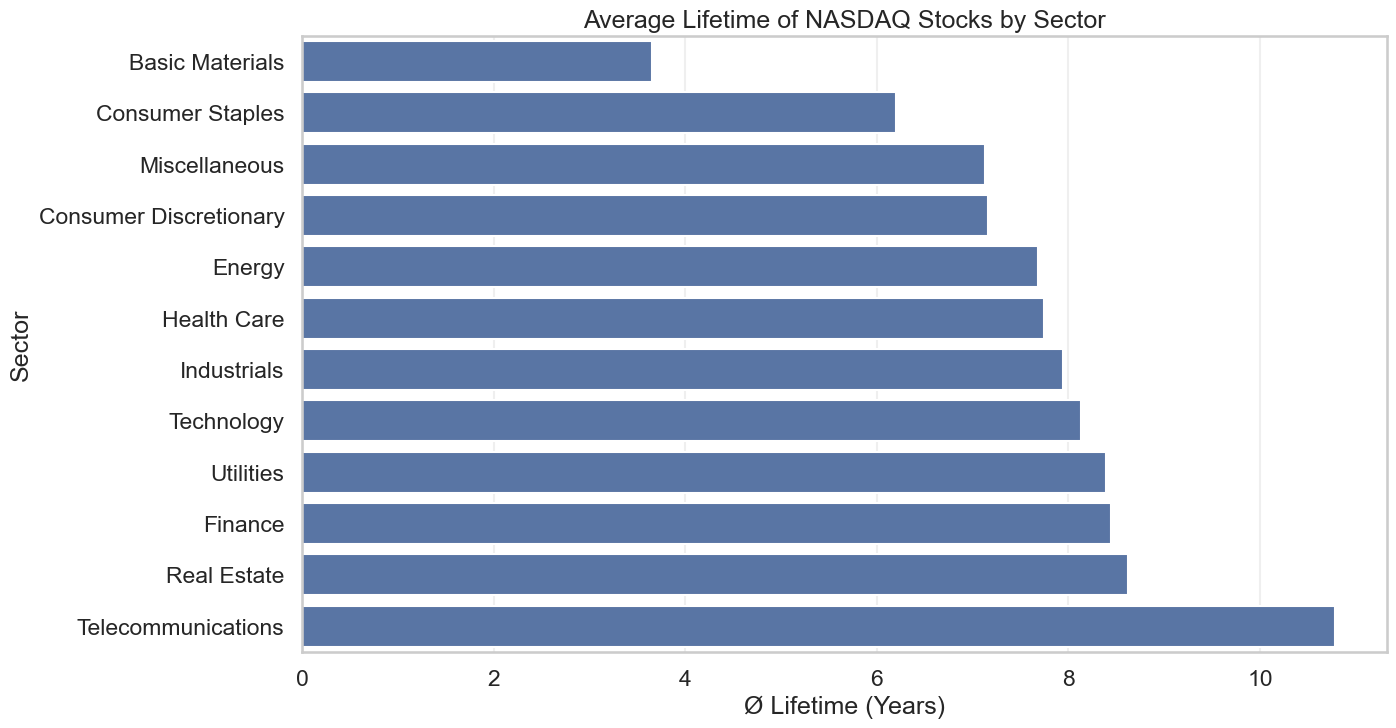

In [61]:

plt.figure(figsize=(14,8))

# barplot
sns.barplot(
    data=lifetimes,
    y="Sector",
    x="lifetime_years",
    estimator="mean",
    errorbar=None,
    order=(
        lifetimes
        .groupby("Sector")["lifetime_years"]
        .mean()
        .sort_values()
        .index
    )
)

plt.xlabel("Ø Lifetime (Years)")
plt.ylabel("Sector")
plt.title("Average Lifetime of NASDAQ Stocks by Sector")
plt.grid(axis="x", alpha=0.3)
plt.savefig(images + "sector_lifetime_nasdaq.png")
plt.show()

This chart is also interesting because it provides a clear picture of the risk and market presence of the individual sectors using the NASDAQ sector composition. Looking at the telecommunications sector, one sees a very long lifetime, which together with the small market share means that there are only a few giants in this sector that can survive for years. A few companies like T-Mobile, Verizon or AT&T have an oligopoly in the telecommunications industry and therefore leave little room for other companies to establish themselves in the sector. Basic Materials is a sector that is very risky because the entire business model usually depends on only one novel material. This leads to a 'boom or bust' phenomenon, which means that the company either becomes very successful or bankrupt. The short lifetime suggests more of the latter. The long lifetime of technology companies is surprising, which might not be expected. On closer consideration it appears logical, because many of the companies date from the dot-com bubble, such as Meta or Amazon. If these companies have a business model so solid that they survive the dot-com bubble, long-term survival is not unlikely.

## Value Change vs Share of Price Loss

### Stock Share with Loss/Gain

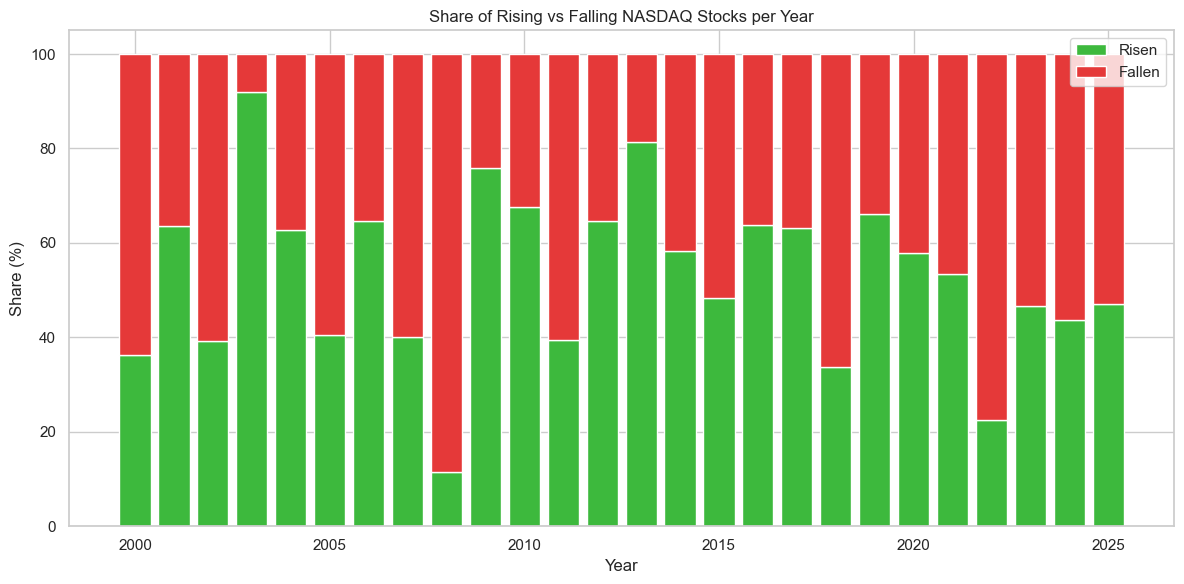

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ensure datetime format
df_nasdaq_weekly_pp["date"] = pd.to_datetime(df_nasdaq_weekly_pp["date"])

df_yearly = df_nasdaq_weekly_pp.copy()

# extract year
df_yearly["year"] = df_yearly["date"].dt.year

# get first open and last close per stock
yearly = (
    df_yearly.sort_values("date")
      .groupby(["ticker", "year"])
      .agg(
          open_start=("open", "first"),
          close_end=("close", "last")
      )
      .reset_index()
)

# get yearly status and map it to string values
yearly["status"] = yearly["close_end"] > yearly["open_start"]
yearly["status"] = yearly["status"].map({True: "Risen", False: "Fallen"})

# aggregate by year and status
summary = (
    yearly
    .groupby(["year", "status"])
    .size()
    .reset_index(name="count")
)

# transform to percent
summary["percent"] = (
    summary["count"]
    / summary.groupby("year")["count"].transform("sum")
    * 100
)

# for clean stacking
pivot = summary.pivot(index="year", columns="status", values="percent").fillna(0)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    pivot.index,
    pivot["Risen"],
    label="Risen",
    color="#3db93d"
)

ax.bar(
    pivot.index,
    pivot["Fallen"],
    bottom=pivot["Risen"],
    label="Fallen",
    color="#e53939"
    
)

yearly_stock = yearly.copy()

ax.set_ylabel("Share (%)")
ax.set_xlabel("Year")
ax.set_title("Share of Rising vs Falling NASDAQ Stocks per Year")
ax.legend()

plt.tight_layout()
plt.savefig(images + "winners_loosers_nasdaq_comp.png")
plt.show()




### Analysis of Actual Performance for Stocks

In [31]:
# only get stocks that actually have a start and end value and are not penny stocks
clean_yearly = yearly_stock[(yearly_stock["open_start"] > 0) & (yearly_stock["close_end"] > 0 ) & (yearly_stock["open_start"] > 5)].copy()

clean_yearly["yearly_return"] = (
    clean_yearly["close_end"] / clean_yearly["open_start"] - 1
)

# aggregate yearly returns per year
agg_return = (
    clean_yearly
    .groupby("year")["yearly_return"]
    .agg(
        avg_yearly_return="mean",
    )
    .reset_index()
)

agg_return_stock = agg_return.copy()

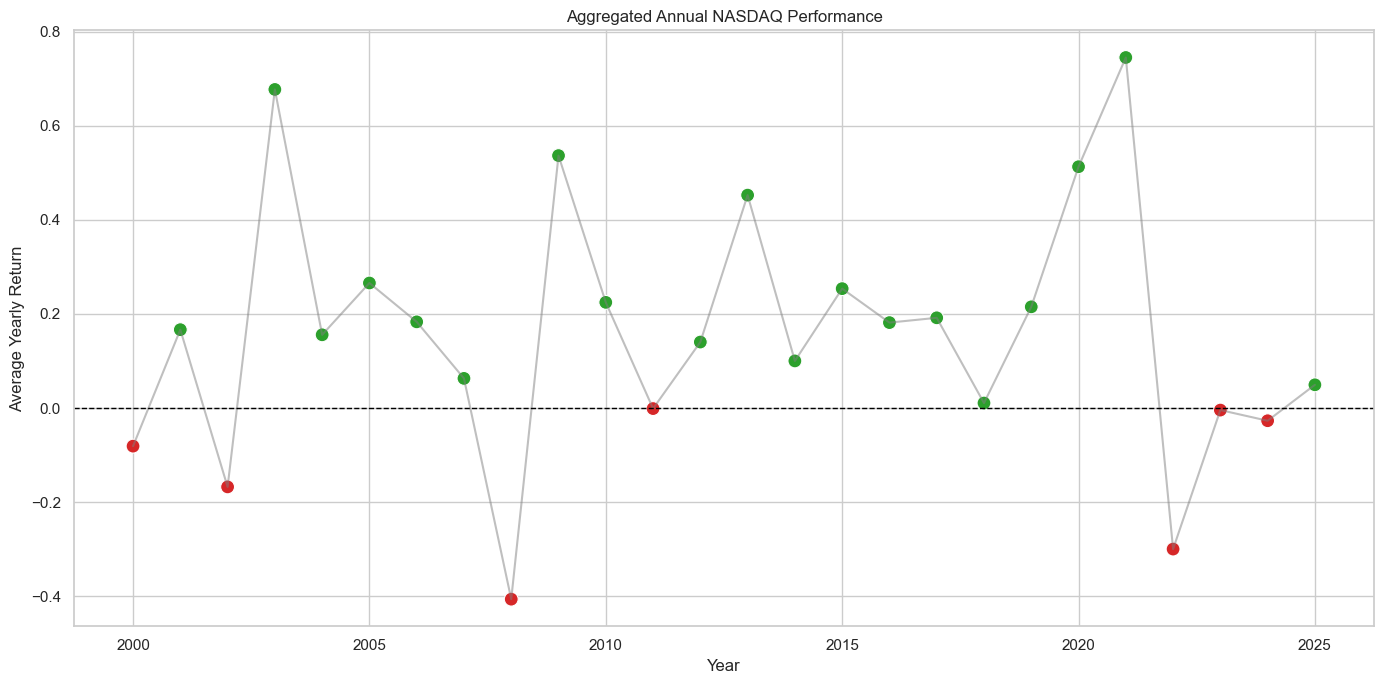

In [32]:
performance = agg_return_stock.copy()

plt.figure(figsize=(14, 7))

# plot a scatter to visualize if the year was good or bad
sns.scatterplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    hue=performance["avg_yearly_return"] > 0,
    palette={True: "#2ca02c", False: "#d62728"},
    s=100,
    legend=False
)

# connect the dots
sns.lineplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    color="gray",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Average Yearly Return")
plt.title("Aggregated Annual NASDAQ Performance")

plt.tight_layout()
plt.savefig(images + "yearly_nasdaq_performance.png")
plt.show()

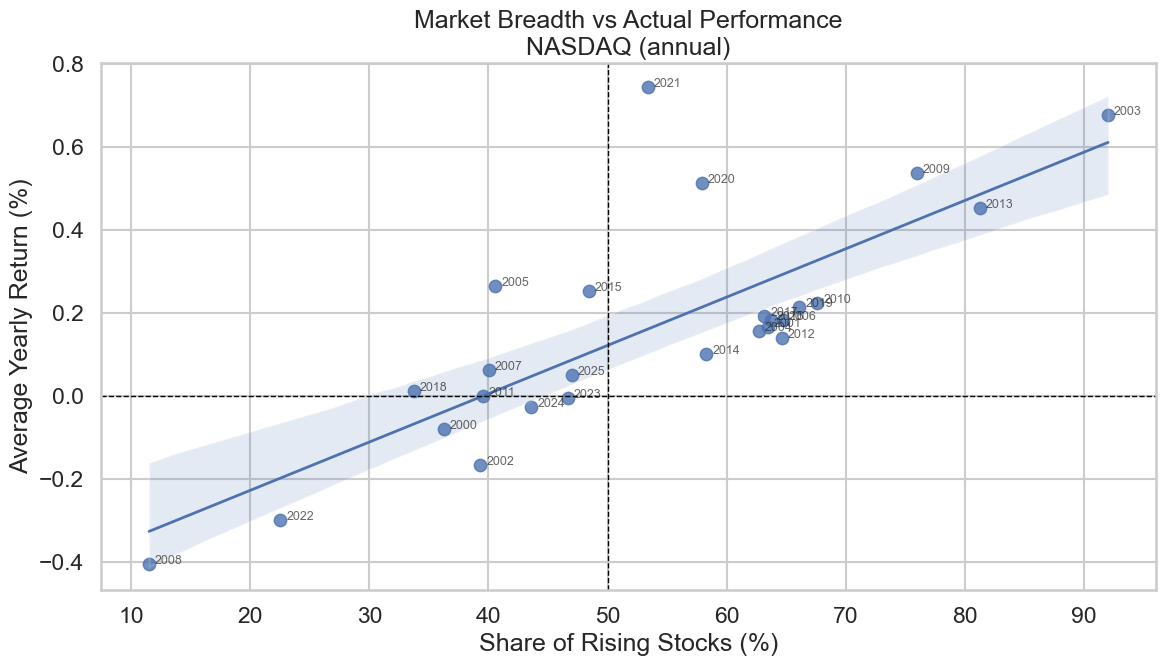

In [33]:
# get every stock that has risen over the years
winner_share = (
    summary[summary["status"] == "Risen"]
    [["year", "percent"]]
    .rename(columns={"percent": "winner_percent"})
)

comparison = agg_return.merge(winner_share, on="year")


sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# scatter plot with linear regression model fit
ax = sns.regplot(
    data=comparison,
    x="winner_percent",
    y="avg_yearly_return",
    scatter_kws={"s": 80, "alpha": 0.8},
    line_kws={"linewidth": 2}
)

# for better axis visualization
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(50, color="black", linewidth=1, linestyle="--")

ax.set_xlabel("Share of Rising Stocks (%)")
ax.set_ylabel("Average Yearly Return (%)")
ax.set_title(
    "Market Breadth vs Actual Performance\nNASDAQ (annual)"
)

# year label for every datapoint
for _, row in comparison.iterrows():
    ax.text(
        row["winner_percent"] + 0.5,
        row["avg_yearly_return"],
        str(int(row["year"])),
        fontsize=9,
        alpha=0.7
    )

plt.tight_layout()
plt.savefig(images + "return_vs_winner-shares.png")
plt.show()

A high share of rising stocks does not necessarily imply strong index performance. The reason is that the metric 'share of rising stocks' only captures the direction of price movements, not their magnitude. Many small price gains across a large number of stocks can be overcompensated by a few strong price losses of individual names — or vice versa. In addition, positive and negative returns can vary considerably in timing and volatility, so average return (index performance) and the proportion of rising stocks reflect different market information. The low agreement between these two measures therefore indicates an asymmetric distribution of returns within the index. An extreme example is 2021, when just over 50% of companies recorded a gain, but performance that year outperformed all others. Looking at an actual index, even stronger growth would be visible, because asset allocation there is weighted by the performance of each company. At the moment, also due to the AI boom, NVIDIA stock is weighted significantly higher than all other stocks in the index with a 10% allocation.

Disclaimer: Catastrophic market years like 2008 would show a much larger loss in reality. But since we only consider the current composition of the NASDAQ, and thus many of the companies listed back then are no longer or were not yet in the NASDAQ, the percentage loss here appears smaller.

### Crypto Share with Loss/Gain

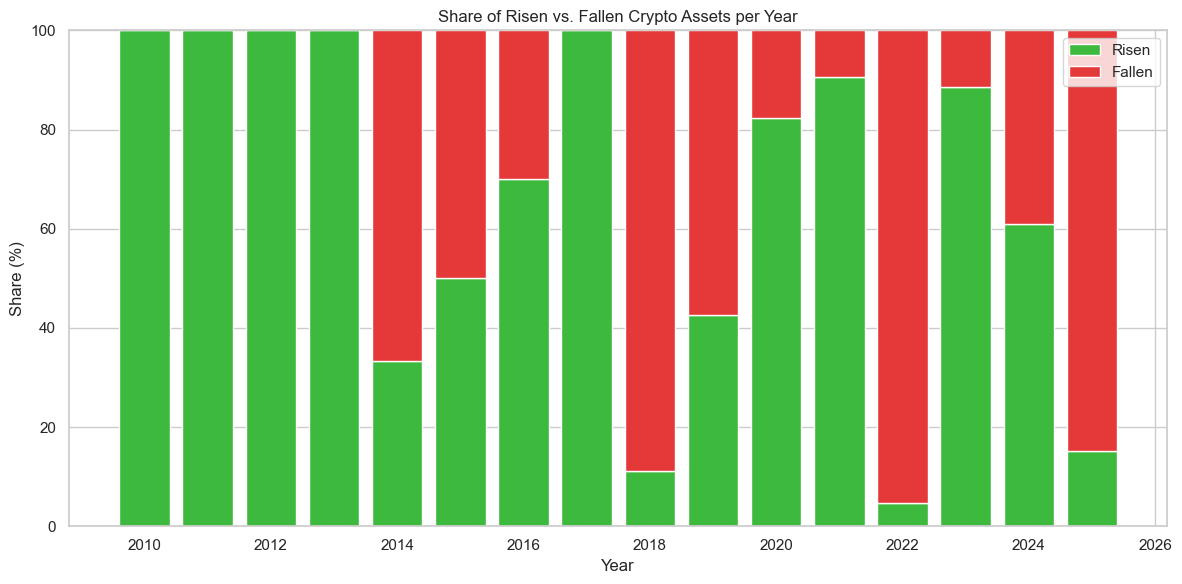

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ensure datetime
df_crypto_weekly_pp["date"] = pd.to_datetime(df_crypto_weekly_pp["date"])

df_yearly = df_crypto_weekly_pp.copy()

# extract year
df_yearly["year"] = df_yearly["date"].dt.year

# open and close per year per stock
yearly = (
    df_yearly.sort_values("date")
      .groupby(["ticker", "year"])
      .agg(
          open_start=("open", "first"),
          close_end=("close", "last")
      )
      .reset_index()
)

# get status
yearly["status"] = yearly["close_end"] > yearly["open_start"]
yearly["status"] = yearly["status"].map({True: "Risen", False: "Fallen"})


summary = (
    yearly
    .groupby(["year", "status"])
    .size()
    .reset_index(name="count")
)

summary["percent"] = (
    summary["count"]
    / summary.groupby("year")["count"].transform("sum")
    * 100
)

# for clean stacking
pivot = summary.pivot(index="year", columns="status", values="percent").fillna(0)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    pivot.index,
    pivot["Risen"],
    label="Risen",
    color="#3db93d"
)

ax.bar(
    pivot.index,
    pivot["Fallen"],
    bottom=pivot["Risen"],
    label="Fallen",
    color="#e53939"
    
)

yearly_crypto = yearly.copy()

ax.set_ylabel("Share (%)")
ax.set_xlabel("Year")
ax.set_title("Share of Risen vs. Fallen Crypto Assets per Year")
ax.legend()

plt.tight_layout()
plt.savefig(images + "winners_loosers_crypto_comp.png")
plt.show()

### Analysis of Actual Performance for Crypto

In [35]:
# only get stocks that actually have a start and end value and are not penny stocks
clean_yearly = yearly_crypto[(yearly_crypto["open_start"] > 0) & (yearly_crypto["close_end"] > 0 )].copy()

clean_yearly["yearly_return"] = np.log2((clean_yearly["close_end"] / clean_yearly["open_start"]))

# get yearly returns per stock per year
agg_return_crypto = (
    clean_yearly
    .groupby("year")["yearly_return"]
    .agg(
        avg_yearly_return="mean",
    )
    .reset_index()
)

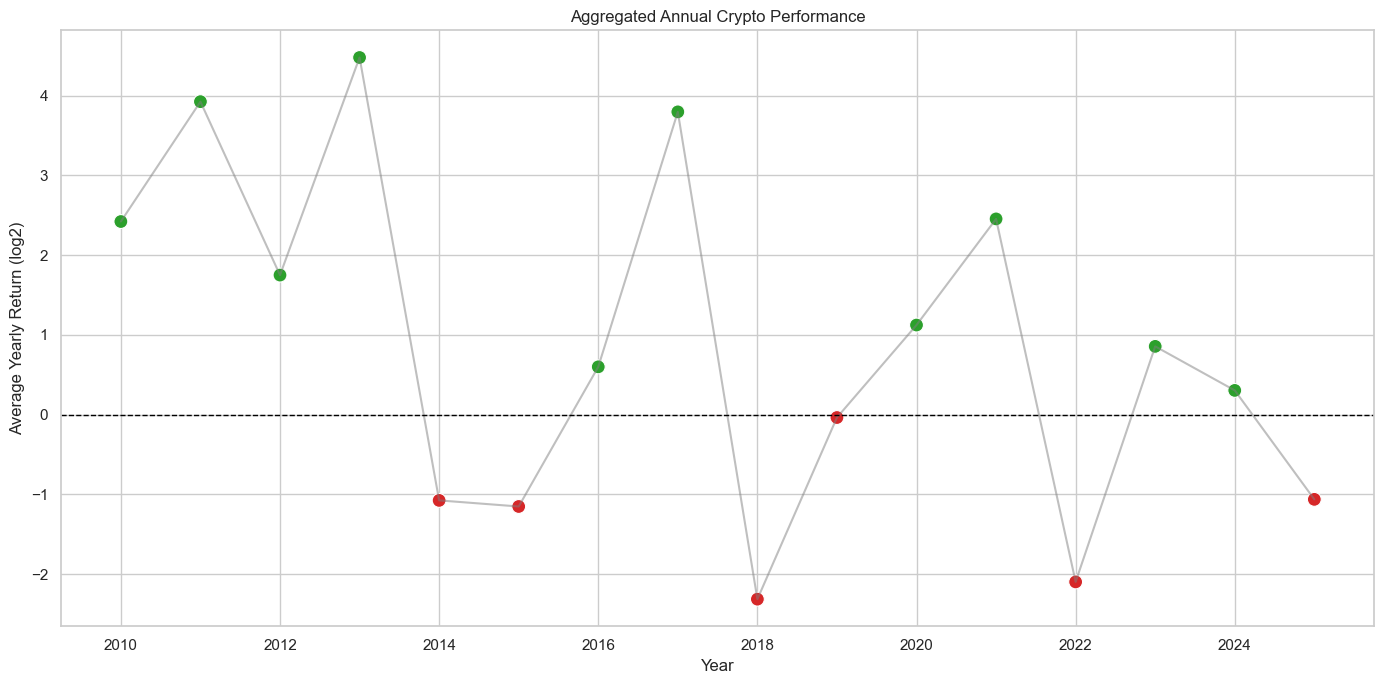

In [36]:
performance = agg_return_crypto.copy()

plt.figure(figsize=(14, 7))

# plot a scatter to visualize if the year was good or bad
sns.scatterplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    hue=performance["avg_yearly_return"] > 0,
    palette={True: "#2ca02c", False: "#d62728"},
    s=100,
    legend=False
)

# connect the dots
sns.lineplot(
    data=performance,
    x="year",
    y="avg_yearly_return",
    color="gray",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Average Yearly Return (log2)")
plt.title("Aggregated Annual Crypto Performance")

plt.tight_layout()
plt.savefig(images + "yearly_cryptoperformance.png")
plt.show()

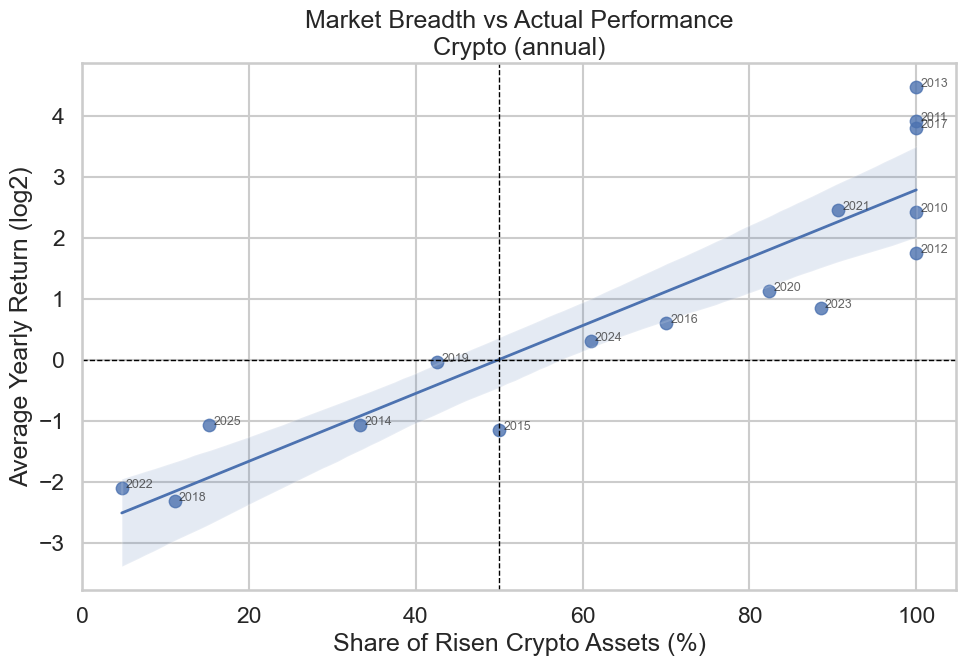

In [37]:
# get Winner stocks
winner_share = (
    summary[summary["status"] == "Risen"]
    [["year", "percent"]]
    .rename(columns={"percent": "winner_percent"})
)

comparison = agg_return_crypto.merge(winner_share, on="year")


sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 7))

# linear regression scatter plot
ax = sns.regplot(
    data=comparison,
    x="winner_percent",
    y="avg_yearly_return",
    scatter_kws={"s": 80, "alpha": 0.8},
    line_kws={"linewidth": 2}
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(50, color="black", linewidth=1, linestyle="--")

ax.set_xlabel("Share of Risen Crypto Assets (%)")
ax.set_ylabel("Average Yearly Return (log2)")
ax.set_title(
    "Market Breadth vs Actual Performance\nCrypto (annual)"
)

# label each datapoint with the corresponding year
for _, row in comparison.iterrows():
    ax.text(
        row["winner_percent"] + 0.5,
        row["avg_yearly_return"],
        str(int(row["year"])),
        fontsize=9,
        alpha=0.7
    )

plt.tight_layout()
plt.savefig(images + "return_vs_winner-crypto.png")
plt.show()

In the analysis of returns for cryptocurrency, it is interesting that there are significantly fewer outliers. Returns thus largely follow the actual share of assets that are rising or falling. There are only a few exceptions with significant deviations from the expected value. The first four years from 2010 to 2013 are of limited significance because at that time there were almost no other cryptocurrencies besides Bitcoin. Nevertheless, you can already see the first boom year in 2013 with a return of ≈+2000%, i.e. more than a 20-fold increase. In subsequent years the asset class showed weak performance, but in 2017 there was another boom that made cryptocurrencies known and launched many new blockchains. Such large gains have not been achieved since, but crypto is now a valid asset class held by many investors in addition to stocks. This is also due, for example, to tax advantages that exist in Germany. You do not have to pay capital gains tax on cryptocurrencies you hold for more than one year. This and the basic idea of a decentralized currency make cryptocurrencies very attractive. Nevertheless, they are often viewed skeptically and investors tend to sell their currencies in times of crisis, as happened in 2022, when interest rates and inflation were high. So one can say that cryptocurrencies no longer have irrational price behavior, but follow macroeconomic conditions.

### Structural Similarities between Crypto and Stocks

At first glance, there are few structural similarities between NASDAQ and crypto. This is mainly due to the core idea behind the asset classes. Stocks are a long-term investment for many investors, associated with steady returns and lower volatility. Crypto, on the other hand, is used by many to achieve supposedly quick wealth, which comes with high volatility and large price gains as well as losses. It becomes interesting if you look at 2022, which was a very bad year for the NASDAQ and the stock market in general. It is also apparent that crypto performed very poorly that year. This suggests that both asset classes are not decoupled from each other, but both follow macroeconomic conditions. Other asset classes such as gold deliver solid returns in such crises because they are considered crisis-proof. In 2022 inflation and the Fed funds rate were at a high not seen in a long time, which causes money to move from uncertain investments to safe ones. Thus investment in crypto and stocks declines, and investment in gold, silver and bonds rises. This primarily shows that cryptocurrencies are by no means independent of macroeconomics despite their 'decentralized' idea.

In [38]:
# volatility for stocks

df_vol_stock = df_nasdaq_weekly_pp.copy()

df_vol_stock["date"] = pd.to_datetime(df_vol_stock["date"])
df_vol_stock["year"] = df_vol_stock["date"].dt.year

df_vol_stock["return"] = (
    df_vol_stock.groupby("ticker")["close"]
    .pct_change()
)

vol_per_coin = (
    df_vol_stock
    .groupby(["ticker", "year"])["return"]
    .std()
    .reset_index(name="volatility")
)

market_vol = (
    vol_per_coin
    .groupby("year")["volatility"]
    .mean()
    .reset_index(name="avg_market_volatility")
)

market_vol["ann_vol"] = market_vol["avg_market_volatility"] * np.sqrt(52)

print(market_vol["ann_vol"])

0     0.804261
1     0.719970
2     0.651193
3     0.648952
4     0.493594
5     1.083732
6     0.736221
7     0.778565
8     1.357464
9     1.157921
10    0.928672
11    1.596487
12    1.352962
13    0.691265
14    1.427453
15    4.050688
16    0.853593
17    0.858141
18    0.873351
19    0.921534
20    2.573117
21    0.831041
22    0.800425
23    0.767506
24    1.071652
25    1.409570
Name: ann_vol, dtype: float64


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/2451563489.py:10: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [39]:
# volatility for stocks

df_vol_crypto = df_crypto_weekly_pp.copy()

df_vol_crypto["date"] = pd.to_datetime(df_vol_crypto["date"])
df_vol_crypto["year"] = df_vol_crypto["date"].dt.year

df_vol_crypto["return"] = (
    df_vol_crypto.groupby("ticker")["close"]
    .pct_change()
)

vol_per_coin = (
    df_vol_crypto
    .groupby(["ticker", "year"])["return"]
    .std()
    .reset_index(name="volatility")
)

market_vol = (
    vol_per_coin
    .groupby("year")["volatility"]
    .mean()
    .reset_index(name="avg_market_volatility")
)

market_vol["ann_vol"] = market_vol["avg_market_volatility"] * np.sqrt(52)

print(market_vol["ann_vol"])


0       1.397262
1       2.328965
2       0.612791
3       3.595682
4       3.608743
5       4.721451
6       2.382031
7     403.403096
8       1.517772
9       1.009410
10      3.239668
11      1.775737
12      0.951565
13      0.876668
14      1.067406
15      3.647222
Name: ann_vol, dtype: float64


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/456514158.py:10: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


Both the volatility of stocks and that of cryptocurrencies should actually be significantly lower. But since we are assuming equal weighting here, a large company like Apple makes as much difference to volatility as a penny stock. In addition, delistings count as a 100% loss, which worsens volatility further. Nevertheless, the differences between NASDAQ and crypto are quite clear. The volatility of cryptocurrencies is significantly higher than that of the NASDAQ in every year. Especially in the boom year 2017, volatility is incredibly high, which means prices changed by a factor of around 1000 on a weekly basis. The main reason is the memecoins that were being pumped at the time. Here the price was artificially driven up with large capital flows only to exit the position with enormous returns, which caused the price to fall again. This principle was often repeated consecutively or across different currencies, which led to the overall astronomical average volatility.

## Correlation Analysis

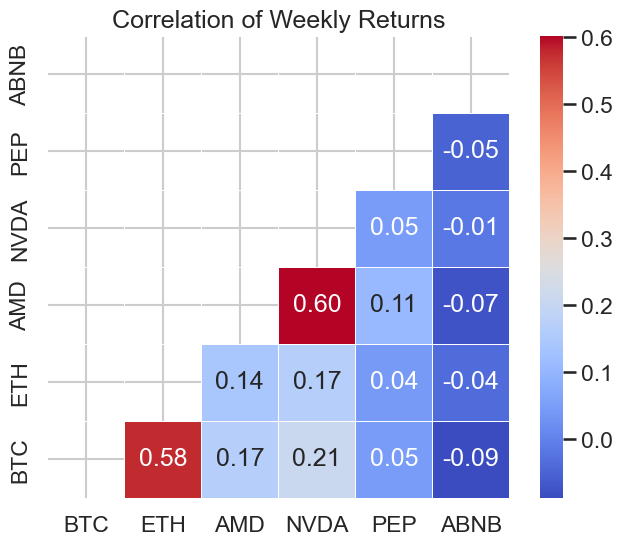

In [40]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

start_date = "2015-08-07" # First ETH trading day

start_date_dt = pd.to_datetime(start_date)

df_crypto_weekly_pp["date"] = pd.to_datetime(df_crypto_weekly_pp["date"])
df_nasdaq_weekly_pp["date"] = pd.to_datetime(df_nasdaq_weekly_pp["date"])

# get DataFrames for each ticker
BTC = df_crypto_weekly_pp[(df_crypto_weekly_pp["ticker"] == "BTC") & (df_crypto_weekly_pp["date"] >= start_date_dt)].copy()
ETH = df_crypto_weekly_pp[(df_crypto_weekly_pp["ticker"] == "ETH") & (df_crypto_weekly_pp["date"] >= start_date_dt)].copy()
AMD = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "AMD") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
NVDA = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "NVDA") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
PEP = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "PEP") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()
ABNB = df_nasdaq_weekly_pp[(df_nasdaq_weekly_pp["ticker"] == "ABNB") & (df_nasdaq_weekly_pp["date"] >= start_date_dt)].copy()

# Calculate pct change week to week
BTC = BTC.sort_values("date").set_index("date")
BTC["weekly_return"] = BTC["open"].pct_change()
BTC["weekly_return"] = BTC["weekly_return"].fillna(0).copy()
BTC = BTC.reset_index()
ETH = ETH.sort_values("date").set_index("date")
ETH["weekly_return"] = ETH["open"].pct_change()
ETH["weekly_return"] = ETH["weekly_return"].fillna(0).copy()
ETH = ETH.reset_index()
AMD = AMD.sort_values("date").set_index("date")
AMD["weekly_return"] = AMD["open"].pct_change()
AMD["weekly_return"] = AMD["weekly_return"].fillna(0).copy()
AMD = AMD.reset_index()
NVDA = NVDA.sort_values("date").set_index("date")
NVDA["weekly_return"] = NVDA["open"].pct_change()
NVDA = NVDA.reset_index()
NVDA["weekly_return"] = NVDA["weekly_return"].fillna(0).copy()
PEP = PEP.sort_values("date").set_index("date")
PEP["weekly_return"] = PEP["open"].pct_change()
PEP = PEP.reset_index()
PEP["weekly_return"] = PEP["weekly_return"].fillna(0).copy()
ABNB = ABNB.sort_values("date").set_index("date")
ABNB["weekly_return"] = ABNB["open"].pct_change()
ABNB = ABNB.reset_index()
ABNB["weekly_return"] = ABNB["weekly_return"].fillna(0).copy()

# concat on the 1st axis
corr_data = pd.concat([BTC["weekly_return"], ETH["weekly_return"], AMD["weekly_return"], NVDA["weekly_return"], PEP["weekly_return"], ABNB["weekly_return"]], axis=1)
corr_data.columns = ["BTC", "ETH", "AMD", "NVDA", "PEP", "ABNB"]
corr = corr_data.corr()

# mask to only show the lower correlation triangle
mask = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))

# correlation heatmap
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

ax.invert_yaxis()

plt.title("Correlation of Weekly Returns")
plt.savefig(images + "correlation_heatmap.png")
plt.show()


# Normalization
BTC["open"] = (BTC["open"] / BTC["open"].iloc[0] * 100).copy()
ETH["open"] = (ETH["open"] / ETH["open"].iloc[0] * 100).copy()
AMD["open"] = (AMD["open"] / AMD["open"].iloc[0] * 100).copy()
NVDA["open"] = (NVDA["open"] / NVDA["open"].iloc[0] * 100).copy()
PEP["open"] = (PEP["open"] / PEP["open"].iloc[0] * 100).copy()
ABNB["open"] = (ABNB["open"] / ABNB["open"].iloc[0] * 100).copy()

colors = {"BTC": "orange", "ETH": "blue", "NVDA": "green", "AMD": "red", "PEP": "pink", "ABNB": "black"}

# plotly plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=BTC.date, y=BTC.open, mode='lines', name="BTC",hovertemplate="%{y:,.1f}%", line=dict(color=colors["BTC"])))
fig.add_trace(go.Scatter(x=ETH.date, y=ETH.open, mode='lines', name="ETH",hovertemplate="%{y:,.1f}%", line=dict(color=colors["ETH"])))
fig.add_trace(go.Scatter(x=AMD.date, y=AMD.open, mode='lines', name="AMD",hovertemplate="%{y:,.1f}%", line=dict(color=colors["AMD"])))
fig.add_trace(go.Scatter(x=NVDA.date, y=NVDA.open, mode='lines', name="NVDA",hovertemplate="%{y:,.1f}%", line=dict(color=colors["NVDA"])))
fig.add_trace(go.Scatter(x=PEP.date, y=PEP.open, mode='lines', name="PEP", hovertemplate="%{y:,.1f}%", line=dict(color=colors["PEP"])))
fig.add_trace(go.Scatter(x=ABNB.date, y=ABNB.open, mode='lines', name="ABNB", hovertemplate="%{y:,.1f}%", line=dict(color=colors["ABNB"])))



fig.update_layout(
    title="Normalized Prices: BTC, ETH, NVDA, AMD, PEP, ABNB",
    xaxis_title="Date",
    yaxis_title="Normalized Price (Base = 100)",
    hovermode="x unified",
    template="seaborn",
    legend=dict(x=0.01, y=0.99),
    height=600,
    width=1050
)
fig.show()

The correlation analysis shows that Bitcoin (BTC) and Ethereum (ETH) have a moderate positive correlation, which indicates that both cryptocurrencies often react to similar market impulses. Especially in the period from 2021 to 2022, the prices moved largely together, followed by a phase of lower momentum and subsequent increased volatility. Despite the correlation, Ethereum shows significantly higher volatility, which indicates a higher beta and thus increased short-term risk compared to Bitcoin.
Between AMD and NVIDIA (NVDA) there is a very high correlation because both companies belong to the same sector and are subject to similar technological and macroeconomic influences. The strong price increase of both stocks is mainly due to the AI boom, with NVIDIA able to benefit earlier and more strongly due to technological competitive advantages.
PepsiCo (PEP), however, shows only a low correlation to cryptocurrencies and technology stocks as a company from a defensive consumer staples sector. Its strong dividend orientation means investors primarily view PEP as an income and stability investment. Therefore, its price behavior is less tied to growth- and technology-driven market movements.
Airbnb (ABNB) moves with a negative correlation independently of the other assets. As the only company it is a pure software company, which means it is driven mainly by macroeconomic circumstances like Fed interest rates and its own innovation.
In addition, a slight correlation between semiconductor manufacturers and cryptocurrencies can be observed. This arises especially from the technological linkage through mining activities, where powerful chips (especially GPUs) play a central role, as well as from common market sentiments in the technology sector. Rising crypto prices temporarily increase demand for computing power and can thus indirectly have positive effects on chip manufacturers. At the same time, both asset classes react sensitively to similar macroeconomic factors such as liquidity conditions, interest rate changes and investor risk appetite. However, the correlation remains limited because the underlying business models and value drivers differ significantly.

## Savings Plan

Create a monthly DataFrame (using only the last day of each month).

In [41]:
# Add a tag for crypto or stock but concat the dataframes for easier calculation
df_nasdaq_weekly_pp["asset_class"] = "stock"
df_crypto_weekly_pp["asset_class"] = "crypto"

df_concat = pd.concat([df_nasdaq_weekly_pp, df_crypto_weekly_pp], ignore_index=True)

# start date for each savingsplan is 2020-01-01
start_date = "2020-01-01"
start_date_dt = pd.to_datetime(start_date)

# default sorting and date formating
df_concat = df_concat.copy()
df_concat["date"] = pd.to_datetime(df_concat["date"])
df_concat = df_concat.sort_values(["ticker", "date"])

# aggregate monthy data for each ticker and pick the last trading day
monthly_df = (
    df_concat
    .groupby(["ticker", df_concat["date"].dt.to_period("M")], as_index=False)
    .last()
)

monthly_df = monthly_df[monthly_df["date"] >= start_date_dt].copy()
print(monthly_df["date"].min())

# prove for a given ticker
test_df = monthly_df[monthly_df["ticker"] == "NVDA"].copy()
print(test_df["date"].dt.year.value_counts().sort_index()) # 12 month for each year should be given

2020-01-20 00:00:00
date
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: count, dtype: int64


Calculate the performance for each ticker.

In [42]:
MONTHLY_INVEST = 100

df_ts = monthly_df.copy()
df_ts = df_ts.sort_values(["ticker", "date"])

# bought units per ticker
df_ts["units_bought"] = MONTHLY_INVEST / df_ts["open"]

# cummulative units for each ticker (bought units get added up to the ones from the last month)
df_ts["cum_units"] = df_ts.groupby("ticker")["units_bought"].cumsum()

# invested capital
df_ts["capital_invested"] = (
    df_ts.groupby("ticker").cumcount() + 1
) * MONTHLY_INVEST

# portfolio value (multiply the current price of the stock with the bought units)
df_ts["portfolio_value"] = df_ts["cum_units"] * df_ts["open"]

Determine the 3 most lucrative assets (2 stocks - 1 cryptocurrency)

In [43]:
summary = (
    df_ts
    .sort_values("date")
    .groupby("ticker", as_index=False)
    .last()[["ticker", "capital_invested", "portfolio_value", "asset_class"]]
)

# total return
summary["total_return"] = (
    summary["portfolio_value"] / summary["capital_invested"] - 1
)

# use the previously defined tags to differentiate between crypto and stock
best = summary.sort_values("total_return", ascending=False)
best_crypto = best[best["asset_class"] == "crypto"].copy()
best_stock = best[best["asset_class"] == "stock"].copy()
print(best_stock.head(2))
print(best_crypto.head(1))

     ticker  capital_invested  portfolio_value asset_class  total_return
2512   QMMM              1500    108611.413820       stock     71.407609
2863   SPRB              5900    407253.252102       stock     68.025975
     ticker  capital_invested  portfolio_value asset_class  total_return
2844    SOL              6900    130413.622416      crypto     17.900525


Unexpected result. Companies like NVIDIA or Palantir would be more likely expected here. An analysis of price performance provides more insight.

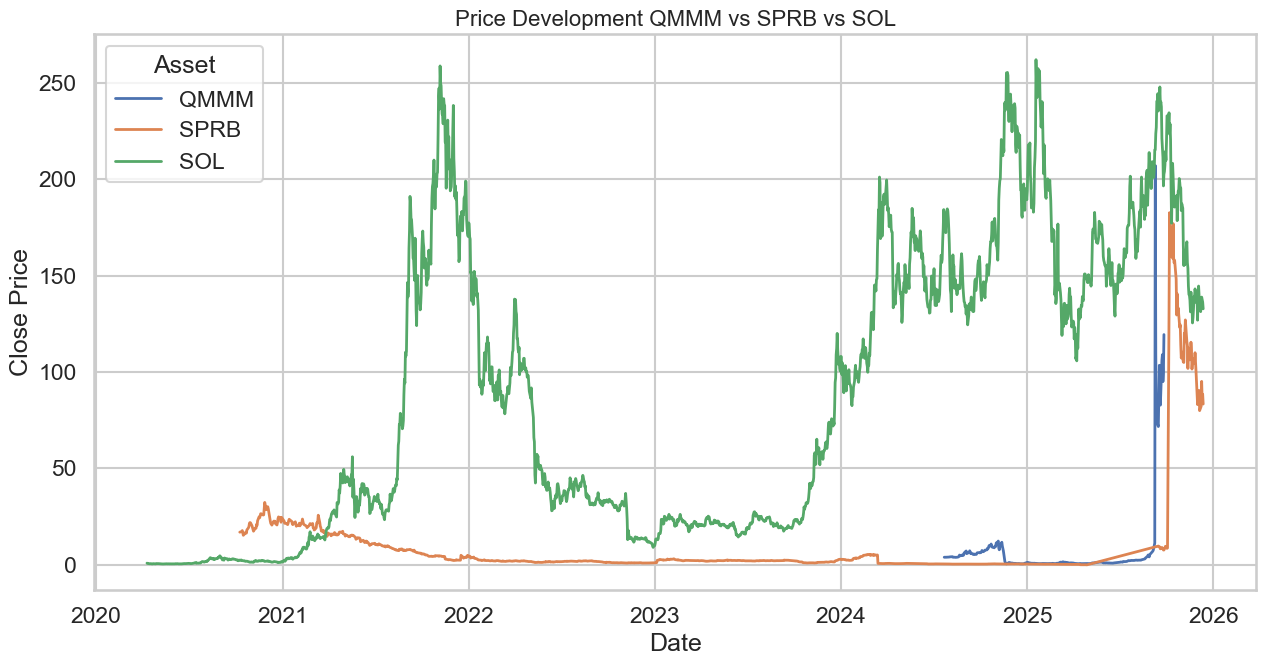

In [44]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# get seperate DataFrames 
stock_split_qmmm = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"]== "QMMM")].copy()
stock_split_sprb = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"]== "SPRB")].copy()
stock_split_sol = df_crypto_daily_pp[(df_crypto_daily_pp["ticker"]== "SOL")].copy()

# reset indices
stock_split_qmmm.reset_index(inplace=True, drop=True)
stock_split_sprb.reset_index(inplace=True, drop=True)
stock_split_sol.reset_index(inplace=True, drop=True)

# set date as index (easier usage as y value)
stock_split_qmmm = stock_split_qmmm.set_index("date")
stock_split_sprb = stock_split_sprb.set_index("date")
stock_split_sol = stock_split_sol.set_index("date")

# reformate date to actual DateTime
stock_split_qmmm.index = pd.to_datetime(stock_split_qmmm.index).normalize()
stock_split_sprb.index = pd.to_datetime(stock_split_sprb.index).normalize()
stock_split_sol.index = pd.to_datetime(stock_split_sol.index).normalize()


qmmm = stock_split_qmmm[["close"]].rename(columns={"close": "price"})
qmmm["asset"] = "QMMM"

sprb = stock_split_sprb[["close"]].rename(columns={"close": "price"})
sprb["asset"] = "SPRB"

sol = stock_split_sol[["close"]].rename(columns={"close": "price"})
sol["asset"] = "SOL"

df_plot = pd.concat([qmmm, sprb, sol])
df_plot = df_plot.reset_index().rename(columns={"index": "date"})

# Seaborn-Plot
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=df_plot,
    x="date",
    y="price",
    hue="asset",
    linewidth=2
)

plt.title("Price Development QMMM vs SPRB vs SOL", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(title="Asset")
plt.tight_layout()
plt.savefig(images + "best_performing_triplet_comp.png")
plt.show()

Obviously the two stocks are so-called penny stocks, which means they had a value of less than one USD for a long time, which leads to a large number of shares being purchased each month. Due to a low market capitalization, these penny stocks are very susceptible to market manipulation, such as a pump (see GameStop short squeeze). Large sums of money are invested in these penny stocks to drive the price enormously higher, which leads to extremely high returns. Usually the prices fall again shortly after investors exit the position with very high gains. The savings plan calculation is correct, but it does not take these penny stocks into account. This performance is of course unpredictable and contradicts any form of market logic. The price development of Solana is even more interesting. Starting at only a few cents, the price increase was very rapid due to the introduction of NFTs, which could be bought with SOL. The exchange FTX was also one of Solana's main supporters, but went bankrupt because of fraud and embezzlement, which also pushed Solana's price down to a low of only 8 USD. At the end of 2023, however, the currency was able to fight back thanks to a strong developer team and reached a new all-time high of 295 USD at the beginning of 2025. The combination of a low price over a long period and a sudden increase makes Solana the cryptocurrency with the best performance. Sources: [1], [2], [3]

Obtain current NASDAQ-100 composition data from Wikipedia.

In [45]:
import pandas as pd
import requests

def get_nasdaq100_list():
    url = 'https://en.wikipedia.org/wiki/Nasdaq-100'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(f"Failed to retrieve data: Status Code {response.status_code}")
        return []

    tables = pd.read_html(response.text)

    # Find the table that has a 'Ticker' column instead of hardcoding index 4
    for i, df in enumerate(tables):
        if 'Ticker' in df.columns:
            print(f"Found components table at index {i}")
            return df['Ticker'].tolist()

    print("Could not find a table with a 'Ticker' column.")
    return []


nasdaq_100_tickers = get_nasdaq100_list()
nasdaq_100_tickers.sort()

# Remove duplicate Google entry (GOOG = Class C, no voting rights)
if "GOOG" in nasdaq_100_tickers:
    nasdaq_100_tickers.remove("GOOG")

print(len(nasdaq_100_tickers))

Found components table at index 5
100


/var/folders/9r/kyrjpzpd11z40v9ccytz62k80000gq/T/ipykernel_87223/2209771859.py:17: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



The following visualizes the savings plan using Plotly. Selecting different time ranges and stocks, as well as cryptocurrencies, is possible.

In [46]:
import plotly.graph_objects as go

all_dropdown_tickers = ["BTC", "ETH"] + nasdaq_100_tickers

fig = go.Figure()

visibility_map = []
trace_index = 0


for ticker in all_dropdown_tickers:
    df_t = df_ts[df_ts["ticker"] == ticker]

    # Invested capital
    fig.add_trace(go.Scatter(
        x=df_t["date"],
        y=df_t["capital_invested"],
        name=f"{ticker} – Invested",
        visible=(ticker == "BTC")
    ))

    # Portfolio value
    fig.add_trace(go.Scatter(
        x=df_t["date"],
        y=df_t["portfolio_value"],
        name=f"{ticker} – Portfolio Value",
        visible=(ticker == "BTC")
    ))

    # Visibility-Mask for Dropdown
    mask = [False] * (2 * len(all_dropdown_tickers))
    mask[trace_index] = True
    mask[trace_index + 1] = True
    visibility_map.append(mask)

    trace_index += 2

    dropdown_buttons = []

# append all tickers (nasdaq + crypto) to the dropdown list
for i, ticker in enumerate(all_dropdown_tickers):
    dropdown_buttons.append(
        dict(
            label=ticker,
            method="update",
            args=[
                {"visible": visibility_map[i]},
                {"title": f"Savings Plan – {ticker}"}
            ]
        )
    )

    # add the option to select different timeframes
    fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=2, label="2Y", step="year", stepmode="backward"),
                dict(count=3, label="3Y", step="year", stepmode="backward"),
                dict(count=4, label="4Y", step="year", stepmode="backward"),
                dict(step="all", label="All")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0.01,
            y=1.15
        )
    ],
    title="Savings Plan - BTC",
    yaxis_title="EUR",
    hovermode="x unified",
    template="seaborn",
    legend=dict(orientation="h", y=-0.2)
)

# add a rangeslider to manually set a prefered timeframe
fig.update_xaxes(
    rangeslider=dict(
        visible=True,
        bgcolor="rgba(200,200,200,0.25)",  # greyed out
        bordercolor="rgba(150,150,150,0.4)",
        borderwidth=1
    )
)

fig.update_xaxes(
    rangeselector=dict(
        y=1.02,        # move up
        x=0.10,
        bgcolor="rgba(255,255,255,1)",
        buttons=[
            dict(count=6, label="6M", step="month", stepmode="backward"),
            dict(count=1, label="1Y", step="year", stepmode="backward"),
            dict(count=2, label="2Y", step="year", stepmode="backward"),
            dict(count=3, label="3Y", step="year", stepmode="backward"),
            dict(count=4, label="4Y", step="year", stepmode="backward"),
            dict(step="all", label="ALL")
        ]
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0,
            y=1.11,          # place higher
            xanchor="left",
            yanchor="top",
            pad={"t": 10}
        )
    ]
)

fig.update_layout(
    height=700,   # adjusted height
    margin=dict(t=120, b=60)
)



fig.show()





When looking at very large and well-known companies like META or NFLX, especially in the last two years, a significant price increase becomes apparent, resulting in returns of over 200% in some cases. In addition, there are clear upward outliers, such as NVDA or PLTR, which achieved returns of up to 900% during the AI boom.
It is striking that in the considered period from 2020 to 2025 there were hardly any negative total returns. This is partly due to the overall very bullish market phase and partly due to the structure of the savings plan investments.
Through the dollar-cost averaging effect, i.e. the regular investment of a fixed amount (in this case 100 € per month), shares are purchased both at high and low prices. This creates an average purchase price that smooths out price fluctuations and reduces the risk of an unfavorable entry point.
Although the return of a savings plan is usually lower than a one-time lump-sum investment at the beginning in a strongly rising market, it reduces risk through time diversification. Savings plans are therefore an effective risk management instrument.
Against this background, the Sharpe ratio is suitable for further analysis, as it relates return to the risk taken and thus enables a risk-adjusted assessment of the savings plans.
Sources: [4], [5]

## Statistical Distribution (Shapiro-Wilk)

In [47]:
# Path to the dataset
DATA_PATH = "./df_nasdaq_daily.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import skew, kurtosis, gaussian_kde


Read in the Nasdaq data with automatic date formatting and error handling (`try-except`) for the file path.

In [48]:
#  Data Setup
try:
    # Get the file and fix date formats
    df_nasdaq = pd.read_csv("./data/df_nasdaq_daily.csv", parse_dates=['date'])

    # Focus on 2000 to 2025
    df_analysis = df_nasdaq[(df_nasdaq['date'] >= '2000-01-01') &
                            (df_nasdaq['date'] <= '2025-12-12')].copy()

    # Drop zero/negative prices so np.log doesn't break
    df_analysis = df_analysis[df_analysis['close'] > 0]
    df_analysis['log_close'] = np.log(df_analysis['close'])

    print(f"Data ready: {len(df_analysis)} rows.")
except FileNotFoundError:
    print("File not found!")

Data ready: 9466174 rows.


Restrict the analysis period (2000–2025) and perform a **log transformation** of closing prices to stabilize the variance.

In [49]:
# --- 2. Getting ready for the plots ---
# Grab a sample of n=5000 to save time on KDE math
sample_size = 5000
df_sample = df_analysis.sample(n=min(len(df_analysis), sample_size), random_state=42)

# Helper function to draw the smooth density curve (KDE)
def plot(data, ax, color='red'):
    kde = gaussian_kde(data) # Calculate density estimate
    x = np.linspace(data.min(), data.max(), 500) # Create smooth x-axis
    ax.plot(x, kde(x), color=color, lw=2, label='Density (KDE)') # Plot it

Calculate skewness and kurtosis as well as perform the **Shapiro-Wilk test** (on a sample) to formally evaluate the normal distribution hypothesis.

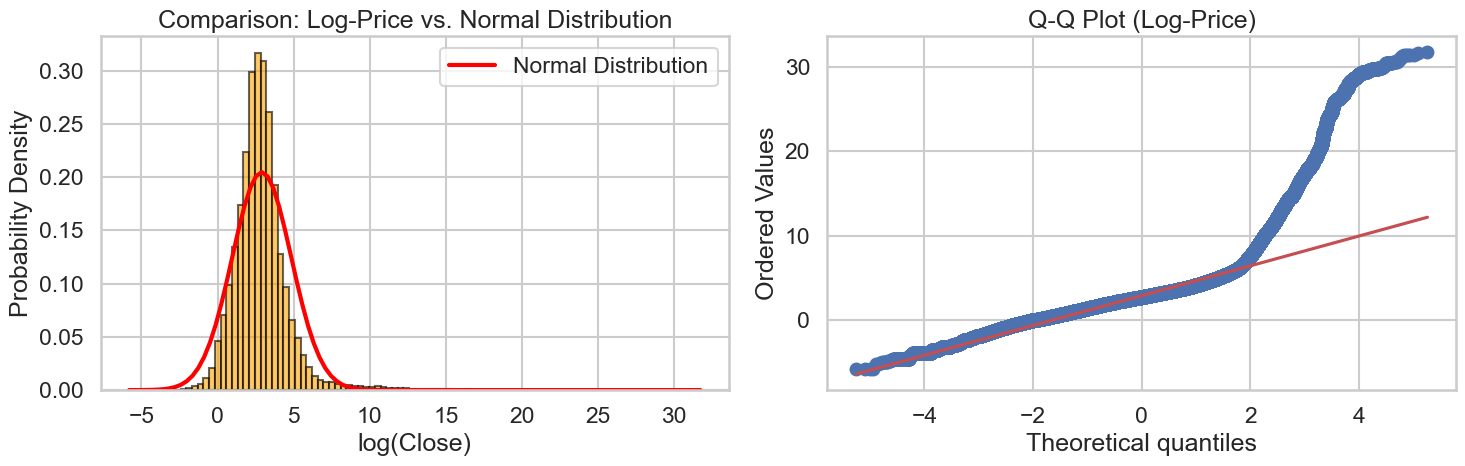

In [50]:
# --- 3. Visual check: Histogram & Q-Q Plot ---
# Setup two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grab the stats for the bell curve
log_data = df_analysis['log_close']
mu = log_data.mean()        # Average log-price
sigma = log_data.std()      # Standard deviation

# --- Plot 1: Histogram + Normal Curve ---
# density=True is key so the red line fits the bars
count, bins, ignored = axes[0].hist(
    log_data,
    bins=100,
    color='orange',
    alpha=0.6,
    edgecolor='black',
    density=True
)

# Plot the "perfect" normal distribution curve for comparison
x = np.linspace(log_data.min(), log_data.max(), 100)
y = stats.norm.pdf(x, mu, sigma) # Math for the normal curve
axes[0].plot(x, y, color='red', lw=3, label='Normal Distribution')

axes[0].set_title("Comparison: Log-Price vs. Normal Distribution")
axes[0].set_xlabel("log(Close)")
axes[0].set_ylabel("Probability Density")
axes[0].legend()

# --- Plot 2: Q-Q Plot ---
# The best way to see if the dots stay on the line
stats.probplot(log_data, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Log-Price)")

plt.tight_layout()
plt.show()

In [51]:
# --- 4. Final Stats & Testing ---
print("\n--- Descriptive Stats (Log-Prices) ---")

# Check if the curve is lopsided (Skewness)
print(f"Skewness: {skew(df_analysis['log_close']):.4f}")

# Check for "Fat Tails" or how peaky the curve is (Kurtosis)
print(f"Kurtosis: {kurtosis(df_analysis['log_close']):.4f}")

# Shapiro-Wilk test: we use the n=5000 sample because the full set is too big
stat, p = stats.shapiro(df_sample['log_close'])
print(f"\nShapiro-Wilk Test (n={len(df_sample)}):")
print(f"Stat: {stat:.4f}, p-value: {p:.4e}")

# Threshold for significance
significance = 0.05

# Final verdict: If p < 0.05, it's NOT normal
if p > significance:
    print("Result: Fail to reject H0. Log-prices look normal.")
else:
    print("Result: Reject H0. Log-prices are NOT normally distributed.")


--- Descriptive Stats (Log-Prices) ---
Skewness: 2.7711
Kurtosis: 18.8187

Shapiro-Wilk Test (n=5000):
Stat: 0.8158, p-value: 4.8644e-60
Result: Reject H0. Log-prices are NOT normally distributed.


Conclusion of the statistical analysis:
The investigation of the log-transformed Nasdaq closing prices shows clear deviations from a normal distribution. With a positive value of about 2.77, the skewness indicates a strong right skew in the data. The frequency of extreme outliers also indicates a very steep distribution, which suggests more frequent extreme values ('fat tails'). Graphically, this is confirmed in the histogram by the long tail to the right and the peaked shape of the curve. The Q-Q plot also illustrates the non-normality, as the observed values deviate massively from the ideal line, especially in the tails. The Shapiro-Wilk test supports these visual impressions with a test statistic of 0.81. Since the resulting p-value of $1.65 	imes 10^{-60}$ is far below the significance level of 0.05, the result is statistically significant. In summary, the null hypothesis of normal distribution must therefore be rejected. The frequency of extreme outliers shows that extreme price jumps or crashes occur much more often than theoretically expected. Investors should therefore be cautious, since the real risk of loss often lies well above mathematical predictions.
Sources: [8], [9]

## Sharpe Ratio Calculation

Objective of this task is to examine small portfolios consisting of a cryptocurrency and NASDAQ-100 stocks based on weekly price data. Random asset combinations should be selected and their price paths synchronized and normalized over time to enable a comparable representation. An equally weighted portfolio should be formed from the weekly returns and its Sharpe ratio calculated. Based on the Sharpe ratio, a qualitative conclusion should be drawn about the risk-adjusted attractiveness and stability of the investment.

Assumption: Since the NASDAQ-100 contains the largest US tech companies, it can be assumed in most cases that the prices of individual stocks will rise. Based on this assumption, it seems logical that the Sharpe ratio increases with diversification, i.e. investing in more stocks. In some cases, the randomly selected stocks and cryptos will of course include values that perform significantly better than diversification across more assets could improve. However, it can be assumed that the Sharpe ratio of 9 stocks is relatively consistently better than that of only 3 or 5 stocks.

In [52]:
import numpy as np
import pandas as pd


CRYPTO_TICKERS = ["BTC", "ETH", "SHIB", "DOGE", "SOL"]
PORTFOLIO_SIZES = [3, 5, 9]
PERIODS_PER_YEAR = 52  # weekly data

# random selection of assets from a given list of companies (in this case nasdaq-100)
def random_portfolio(df, nasdaq_100_list, n_assets, include_crypto=True):
    stocks = df.loc[
        (df["asset_class"] == "stock") &
        (df["ticker"].isin(nasdaq_100_list)),
        "ticker"
    ].unique()

    if include_crypto:
        crypto = df.loc[
            (df["asset_class"] == "crypto") &
            (df["ticker"].isin(CRYPTO_TICKERS)), # also use predefined list of cryptocurrencies
            "ticker"
        ].unique()

        # pick one random cryptocurrency
        c = np.random.choice(crypto, 1)
        # pick the rest of "n" stocks
        s = np.random.choice(stocks, n_assets - 1, replace=False)
        return list(c) + list(s)

    return list(np.random.choice(stocks, n_assets, replace=False))


# create a timeseries from the tickers list nasdaq-100 list
def portfolio_timeseries(df, tickers, start_value=100):
    prices = (
        df[df["ticker"].isin(tickers)]
        .pivot(index="date", columns="ticker", values="close")
        .dropna()
    )

    # get the change in prices (in percent)
    returns = prices.pct_change().dropna()
    portfolio_returns = returns.mean(axis=1)

    portfolio_index = (1 + portfolio_returns).cumprod() * start_value

    return portfolio_index, portfolio_returns


# calculate sharpe ratio
def sharpe_ratio(returns, rf=0.0, periods_per_year=52):
    # translates annual rf in periodic rf
    rf_periodic = rf / periods_per_year

    excess_returns = returns - rf_periodic # default is rf_periodic = 0 (since we have to guranteed return)

    sharpe = (
        excess_returns.mean()
        / excess_returns.std(ddof=1)
    ) * (periods_per_year ** 0.5)

    return sharpe




results = []

# compare the 3 portfolio sizes
for n in PORTFOLIO_SIZES:
    tickers = random_portfolio(
        df=df_concat,
        nasdaq_100_list=nasdaq_100_tickers,
        n_assets=n,
        include_crypto=True
    )

    # get the timeseries and sharpe ratio for each
    _, portfolio_returns = portfolio_timeseries(df_concat, tickers)
    sr = sharpe_ratio(portfolio_returns)

    results.append({
        "Number of Assets": n,
        "Tickers": ", ".join(tickers),
        "Sharpe Ratio": round(sr, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)


   Number of Assets                                            Tickers  \
0                 3                                    ETH, VRSK, NFLX   
1                 5                        SHIB, CTAS, IDXX, CCEP, ADI   
2                 9  SHIB, PANW, COST, CPRT, MDLZ, SBUX, AEP, CMCSA...   

   Sharpe Ratio  
0          1.35  
1          0.64  
2          0.68  


Repeated execution of the code makes it clear that diversification with random assets is not effective and does not consistently yield a better Sharpe ratio than just 3 assets. It is interesting that 'memecoins' like SHIB or DOGE have a significant influence on the Sharpe ratio because they have incredibly high volatility but only low returns. This influence is particularly visible with only 3 assets, because their share is highest there. The influence decreases when more assets are in the portfolio and crypto makes up a smaller share. Hedge funds also use this effect by allocating a small portion of their portfolio to crypto to leverage return opportunities without endangering the overall portfolio's volatility. To improve the Sharpe ratio further, other asset classes such as precious metals, commodities, bonds, options or real estate should also be considered, as these perform differently in crises and thus reduce volatility. Sources: [6], [7]

## Historical Market Events

The goal of this task is to construct an aggregated time series that maps the overall development of the NASDAQ-100. For this, the weekly closing prices of all NASDAQ-100 stocks contained in the dataset are used and converted into weekly returns. The individual returns are combined into an equally weighted index that starts at a defined initial value and reflects cumulative market performance. The resulting time series is to be visualized interactively with Plotly and serve as a basis for annotating historical events. Which events are used for these markers can be chosen freely.

In [53]:
# possible important events in stock market history
raw_events = [
    {"date": "2008-09-15", "label": "Lehman Brothers Bankruptcy", "type": "crisis"},
    {"date": "2010-05-06", "label": "Flash Crash", "type": "crisis"},
    {"date": "2016-06-23", "label": "Brexit Referendum", "type": "political"},
    {"date": "2020-03-11", "label": "COVID-19 Pandemic", "type": "crisis"},
    {"date": "2021-01-06", "label": "US Capitol Riot", "type": "political"},
    {"date": "2022-03-16", "label": "Fed Rate Shift", "type": "monetary"},
    {"date": "2023-03-10", "label": "SVB Bank Crisis", "type": "crisis"},
    {"date": "2022-11-30", "label": "ChatGPT Launch", "type": "tech"},
    {"date": "2025-04-02", "label": "Liberation Day", "type": "political"}
]
## generated with Gemini

# the dates need to be fitted to the monday to match with the weekly_dataframe
def align_to_monday(date_str):
    date = pd.to_datetime(date_str)
    monday = date - pd.to_timedelta(date.weekday(), unit="d")
    return monday

# calculate timeseries for a given ticker off a given ticker list
def nasdaq_index(df, tickers):
    prices = (
        df[df["ticker"].isin(tickers)]
        .pivot(index="date", columns="ticker", values="close")
        .dropna(axis=1)
    )

    returns = prices.pct_change().dropna()
    index = (1 + returns.mean(axis=1)).cumprod() * 100

    return index

# calculate the nasdaq-100 index for the weekly dataframe
nasdaq_ts = nasdaq_index(df_nasdaq_weekly_pp, nasdaq_100_tickers)

market_events = []
for event in raw_events:
    aligned_date = align_to_monday(event["date"])
    market_events.append({
        "date": aligned_date,
        "label": event["label"],
        "type": event["type"]
    })


fig = go.Figure()

marker_dates = []
marker_values = []
marker_texts = []
marker_colors = []


# scatter for every entry of the DataFrame
fig.add_trace(
    go.Scatter(
        x=nasdaq_ts.index,
        y=nasdaq_ts.values,
        mode="lines",
        name="NASDAQ-100 (equal-weighted)",
        line=dict(width=2)
    )
)

color_map = {
    "crisis": "red",
    "monetary": "blue",
    "political": "green"
}

# add values to simplified lists
for event in market_events:
    if event["date"] in nasdaq_ts.index:
        marker_dates.append(event["date"])
        marker_values.append(nasdaq_ts.loc[event["date"]])
        marker_texts.append(f"{event['label']}<br>Date: {event['date']}<br>Index: {nasdaq_ts.loc[event['date']]:.2f}")
        marker_colors.append(color_map.get(event["type"], "gray"))

# all markers in single Trace
fig.add_trace(
    go.Scatter(
        x=marker_dates,
        y=marker_values,
        mode="markers",
        marker=dict(size=12, color=marker_colors, symbol="square"),
        hoverinfo="text",
        hovertext=marker_texts,
        name="Important Events"
    )
)




fig.update_layout(
    title="NASDAQ-100 with Market-Moving Events (Markers)",
    xaxis_title="Date",
    yaxis_title="Index (Start = 100)",
    hovermode="x unified",
    height=600,
    width=1050,
    template="seaborn",
    showlegend=False
)

fig.write_image(images + "historic_events.png", scale=2.0)
fig.show()


Disclaimer: The chart shows the price development using current values of the index. The actual value of the index is different, but visually it only differs marginally from this depiction! Especially historical values (<2015) are less pronounced than in reality!

This graph nicely shows how individual events influence the entire NASDAQ price. Particularly noticeable is the abrupt market collapse due to the COVID-19 pandemic in 2020. It is also interesting how the raised interest rates can cause a stagnating or declining market. In 2022 the Fed raised the interest rate significantly to combat inflation, which was especially high that year. This led to less investment in the stock market, or to a shift into other assets like gold or bonds. Trump's 'Liberation Day' is also surprising. The decision of one man can shake the entire market.

# Model Building

## Training and Optimization

In [54]:
import pandas as pd
import yfinance as yf

# Path to data
data = "./data/"
images = "./images/"

df_nasdaq_daily_pp = pd.read_csv(data + "df_nasdaq_daily.csv")
df_nasdaq_weekly_pp = pd.read_csv(data + "df_nasdaq_weekly.csv")
df_crypto_daily_pp = pd.read_csv(data + "df_crypto_daily.csv")
df_crypto_weekly_pp = pd.read_csv(data + "df_crypto_weekly.csv")
df_nasdaq_meta_pp = pd.read_csv(data + "df_nasdaq_meta.csv")

In [55]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

df = df_nasdaq_daily_pp[df_nasdaq_daily_pp["ticker"] == "NVDA"].copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Create Target Variable
df["target"] = df["close"].shift(-1)


# Feature Engineering:
# Returns
df["return_1"] = df["close"].pct_change()

# Lag-Feature
df["close_lag_1"] = df["close"].shift(1)

# Rolling Features
df["sma_5"] = df["close"].rolling(5).mean()
df["sma_20"] = df["close"].rolling(20).mean()
df["vol_20"] = df["return_1"].rolling(20).std()
df["close_x_vol"] = df["close"] * df["vol_20"]

df = df.dropna().reset_index(drop=True)

# end Feature Engineering

# create data splits
train_df = df[(df["date"] >= "2015-01-01") & (df["date"] <= "2023-12-31")]
val_df   = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]
test_df  = df[(df["date"] >= "2025-01-01") & (df["date"] <= "2025-12-31")]

# create different feature sets to see which one is best
feature_sets = [
    ["return_1"],

    ["return_1", "close_lag_1"],

    ["return_1", "close_lag_1", "sma_5"],

    ["return_1", "close_lag_1", "sma_5", "sma_20"],

    ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20"],

    ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20", "close_x_vol"],
]


results = []

for features in feature_sets:
    X_train = train_df[features]
    y_train = train_df["target"]

    X_val = val_df[features]
    y_val = val_df["target"]

    # scaling of feature data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    val_preds = model.predict(X_val_scaled)
    # Get Mean Absolute Percentage Error
    val_mape = mean_absolute_percentage_error(y_val, val_preds)

    results.append({
        "features": features,
        "val_mape": val_mape
    })

    print(f"Features: {features}")
    print(f"Validation MAPE: {val_mape:.4f}\n")



Features: ['return_1']
Validation MAPE: 0.8888

Features: ['return_1', 'close_lag_1']
Validation MAPE: 0.0329

Features: ['return_1', 'close_lag_1', 'sma_5']
Validation MAPE: 0.0325

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20']
Validation MAPE: 0.0323

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20']
Validation MAPE: 0.0323

Features: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20', 'close_x_vol']
Validation MAPE: 0.0322



The last feature set achieves the smallest mean absolute percentage error. Therefore it will be used for our predictions. Before that, we look at the mean absolute percentage error on the test dataset.

In [56]:
results_df = pd.DataFrame(results)
best_features = results_df.sort_values("val_mape").iloc[0]["features"]

print("Bestes Feature-Set:", best_features)

X_train_val = pd.concat([train_df, val_df])[best_features]
y_train_val = pd.concat([train_df, val_df])["target"]

X_test = test_df[best_features]
y_test = test_df["target"]

scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_val_scaled, y_train_val)

test_preds = final_model.predict(X_test_scaled)
test_mape = mean_absolute_percentage_error(y_test, test_preds)

print(f"Test MAPE (2025): {test_mape:.4f}")


Bestes Feature-Set: ['return_1', 'close_lag_1', 'sma_5', 'sma_20', 'vol_20', 'close_x_vol']
Test MAPE (2025): 0.0278


The model has only a MAPE of 2.78%. That is a comparatively good value. Whether the model is actually usable remains to be seen.

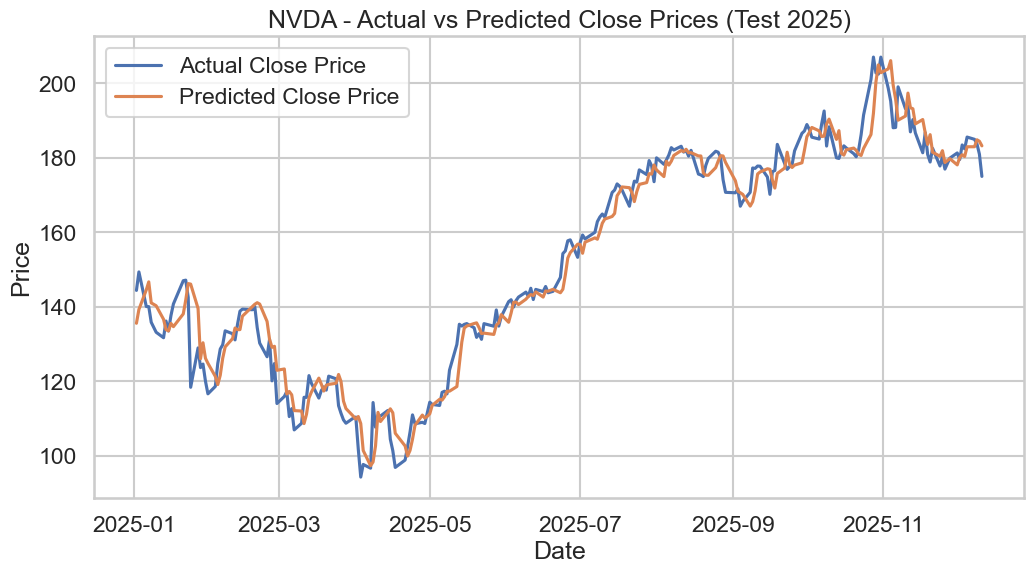

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(test_df["date"], y_test.values, label="Actual Close Price")
plt.plot(test_df["date"], test_preds, label="Predicted Close Price")
plt.title("NVDA - Actual vs Predicted Close Prices (Test 2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.savefig(images + "model_pred.png")
plt.show()

The correlation between prediction and actual value is high because the value of the day before the prediction is always known, which of course is an optimal condition and does not reflect reality. The errors that occur during the prediction would propagate, because the predicted price is used as the basis for the new prediction. In a previous attempt 'close' was used as a feature, but this led to that feature becoming too dominant and the model learned that the price of the next day is approximately the price of today, which ex-post leads to good performance but is practically (autoregressive) meaningless. With the current selection of features, the model learns better to predict price changes.

## Ex-Post

In [58]:
# NVIDIA-Ticker
ticker = "NVDA"

train_start_date = pd.to_datetime("2015-01-01")

df_nasdaq_daily_pp["date"] = pd.to_datetime(df_nasdaq_daily_pp["date"])

df = df_nasdaq_daily_pp[(df_nasdaq_daily_pp["ticker"] == ticker) & (df_nasdaq_daily_pp["date"] >= train_start_date)].copy()

# Get missing data from yfinance
yf_data = yf.download(
            ticker,
            start="2025-12-12",
            end="2026-01-30",
            auto_adjust=True,
            progress=False,
            group_by="ticker"
        )


# adjust yfinance date to fit the given schema
df_yf = (
                yf_data[ticker]
                .reset_index()
                .rename(columns={"Date": "date", "Open": "open", "Close": "close"})
                [["date", "open", "close"]]
            )

df_yf["date"] = pd.to_datetime(df_yf["date"])
df_yf = df_yf.sort_values("date")
df_yf["ticker"] = ticker

# We put df_yf last so that in drop_duplicates, 'last' keeps the fresh yfinance data
df_combined = pd.concat([df, df_yf], ignore_index=True)

# This keeps the yfinance version if there's a date overlap
df_hist = df_combined.drop_duplicates(subset=["ticker", "date"], keep="last")

# Sort for cleanliness
df_hist = df_hist.sort_values(["ticker", "date"]).reset_index(drop=True)

# same features
df_hist["return_1"] = df_hist["close"].pct_change()
df_hist["close_lag_1"] = df_hist["close"].shift(1)
df_hist["sma_5"] = df_hist["close"].rolling(5).mean()
df_hist["sma_20"] = df_hist["close"].rolling(20).mean()
df_hist["vol_20"] = df_hist["return_1"].rolling(20).std()
df_hist["close_x_vol"] = df_hist["close"] * df_hist["vol_20"]

# target variable
df_hist["target"] = df_hist["close"].shift(-1)

df_hist = df_hist.dropna().reset_index(drop=True)

# training data 
train_val = df_hist[df_hist["date"] <= "2026-01-18"]
features = ["return_1", "close_lag_1", "sma_5", "sma_20", "vol_20", "close_x_vol"]

X_train_val = train_val[features]
y_train_val = train_val["target"]

#scaling
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)

model = LinearRegression()
model.fit(X_train_val_scaled, y_train_val)


# Days until 18th January
df_expost = train_val.copy()
X_expost = df_expost[features].iloc[-1:]
X_expost_scaled = scaler.transform(X_expost)
pred_expost = model.predict(X_expost_scaled)[0]
print(f"Actual Price: {df_hist[df_hist["date"] == "2026-01-19"]["close"]}")
print(f"Ex-post Prognose (19.01.2026): {pred_expost:.2f}")

Actual Price: Series([], Name: close, dtype: float64)
Ex-post Prognose (19.01.2026): 186.77


## Autoregressive

In [59]:
# startdate
start_date = pd.to_datetime("2026-01-09")

df_auto = df_hist[df_hist["date"] <= start_date].copy()

# Get all trading days until the 19th
pred_dates = pd.date_range(
    start=start_date + pd.Timedelta(days=1),
    end="2026-01-20",
    freq="B"
)

preds = []
last_df = df_auto.copy()

for d in pred_dates:

    # Get last day
    last_row = last_df.iloc[-1]

    # create feature vector
    X_last = pd.DataFrame([{
        "return_1": last_row["return_1"],
        "close_lag_1": last_row["close_lag_1"],
        "sma_5": last_row["sma_5"],
        "sma_20": last_row["sma_20"],
        "vol_20": last_row["vol_20"],
        "close_x_vol": last_row["close_x_vol"]
    }])

    # Scale
    X_last_scaled = scaler.transform(X_last)

    # Prediction for t+1
    y_hat = model.predict(X_last_scaled)[0]
    preds.append({"date": d, "pred": y_hat})

    # calculate return based on new prediction
    last_close = last_row["close"]
    new_return = y_hat / last_close - 1

    # get last entries for recalculation rolling averages and volatility
    last_5_closes = pd.concat([last_df["close"].iloc[-4:], pd.Series([y_hat])])
    last_20_closes = pd.concat([last_df["close"].iloc[-19:], pd.Series([y_hat])])
    last_20_returns = pd.concat([last_df["return_1"].iloc[-19:], pd.Series([new_return])])

    new_row = pd.DataFrame({
        "ticker": ["NVDA"],
        "date": [d],
        "close": [y_hat],
        "open": [np.nan],
        "return_1": [new_return],
        "close_lag_1": [last_close],
        "sma_5": [last_5_closes.mean()],
        "sma_20": [last_20_closes.mean()],
        "vol_20": [last_20_returns.std()],
        "close_x_vol": [last_20_returns.std() * y_hat],
        "target": [np.nan]
    })

    # append new predicted day
    last_df = pd.concat([last_df, new_row], ignore_index=True)

# predition time series
df_preds_auto = pd.DataFrame(preds)


## Comparison with Actual Performance

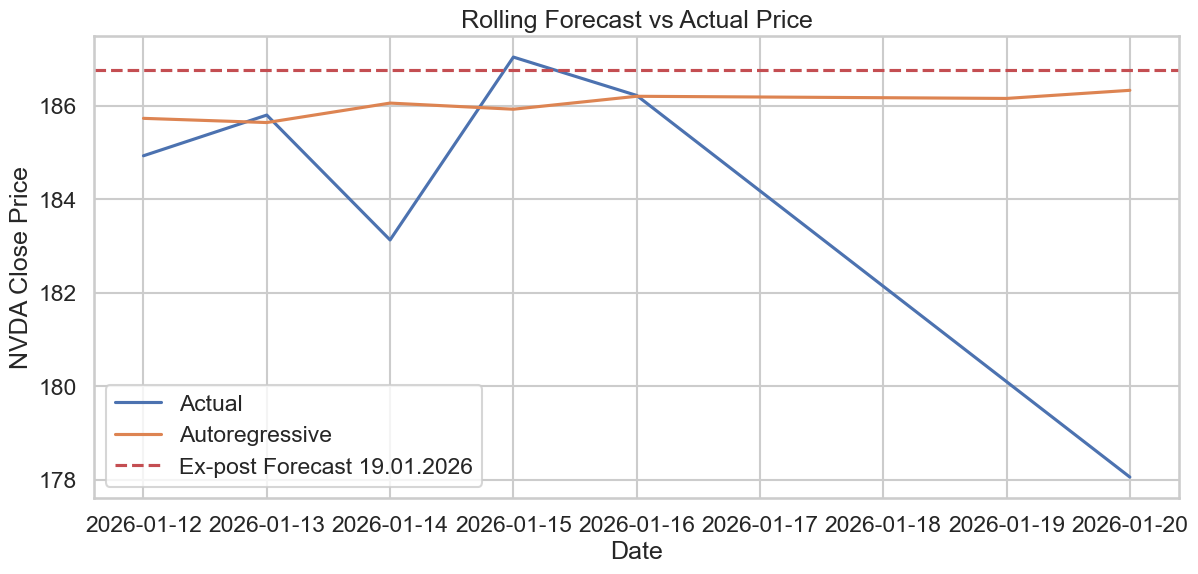

In [60]:
# Actual price
df_actual = df_hist[(df_hist["date"] >= start_date + pd.Timedelta(days=1)) & (df_hist["date"] <= "2026-01-20")]

plt.figure(figsize=(14,6))
plt.plot(df_actual["date"], df_actual["close"], label="Actual")
plt.plot(df_preds_auto["date"], df_preds_auto["pred"], label="Autoregressive")
plt.axhline(y=pred_expost, color="r", linestyle="--", label="Ex-post Forecast 19.01.2026")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.title("Rolling Forecast vs Actual Price")
plt.legend()
plt.grid(True)
plt.savefig(images + "models.png")
plt.show()


To actually want to predict price development, one needs more information about the health of the company or macroeconomic factors such as interest rates. For this, ARIMAX is suitable, which is an extension of classical time series models that considers exogenous factors such as volatility, interest rates or macro data in addition to past returns. Unlike pure linear regression, ARIMAX respects the temporal dependence of price data and can correctly model non-stationary series through differencing. Therefore ARIMAX is better suited for short-term forecasting of returns, especially when known external drivers play a role.
Source: [14]

# Conclusion and Summary

In this project work, various stocks and cryptocurrencies were analyzed to better understand the development of prices and the associated risk. The investigation led to the following key insights:
1. Data preparation and quality
At the beginning, raw data was reconciled with the splits of the individual stocks. In doing so, it became apparent that the data were not always complete. Gaps were supplemented with data from the yfinance API. This step was the necessary basis so that later calculations of return and risk as well as the visualizations could deliver correct results.
2. Risk-return profile
A clear difference emerged between the different asset classes:
Stability: Classic values like PepsiCo showed very low volatility but had little correlation with growth stocks or cryptocurrencies. These classic names barely fluctuated and therefore offer security, albeit with limited upside potential. Here dividends would be important, but they cannot be determined from the data.
Growth dynamics: With technology stocks like NVIDIA and especially cryptocurrencies like Bitcoin or Solana, enormous price jumps could be observed. However, these opportunities come with much higher fluctuation, which requires greater risk tolerance.
3. Analysis of loss days and performance
An important point of the analysis was the ratio between the percentage share of stocks with price losses and the actual value performance. It was found that a high number of stocks with losses does not automatically mean poor performance. With values like Bitcoin or NVIDIA, a few but very strong positions were enough to offset the often smaller companies with losses. With crypto, however, it could be observed that share and price performance go together and one can infer the other.
4. Savings plan and Sharpe ratio
This analysis is interest-driven and examines whether a good Sharpe ratio can be achieved by randomly mixing assets. In this way, you could build a portfolio from random values of the NASDAQ-100 and minimize risk in terms of volatility. Unfortunately, building a portfolio requires somewhat more and especially more asset classes like precious metals or real estate to create a truly safe and performant portfolio.
5. Linear regression
Linear regression is unfortunately not well suited for predicting stock prices. More information is needed such as interest rates, innovation or a company's profit rate to make well-founded forecasts. Since the model only has knowledge about previous price developments, it struggles to predict price changes without additional information.
Overall conclusion
In summary, a balanced portfolio consists of a combination of safety and risk. While stable stocks provide calm in the portfolio, cryptocurrencies and high-growth tech stocks serve as return drivers. Success in the stock market requires conscious risk management rather than avoidance.

# Sources

1. [Short Squeeze – boerse.de](https://www.boerse.de/boersenlexikon/Short-Squeeze)
2. [Solana (Blockchain) – Wikipedia](https://de.wikipedia.org/wiki/Solana_(Blockchain))
3. [Bankruptcy of FTX – Wikipedia](https://en.wikipedia.org/wiki/Bankruptcy_of_FTX#:~:text=The%20bankruptcy%20of%20FTX%2C%20a,the%20impetus%20for%20its%20bankruptcy.)
4. [Cost Average Effekt – Zendepot](https://zendepot.de/etf/cost-average-effekt)
5. [Nasdaq-100 – Wikipedia](https://en.wikipedia.org/wiki/Nasdaq-100)
6. [2 Hedgefonds setzt Krypto – Yahoo Finance](https://de.finance.yahoo.com/nachrichten/2-hedgefonds-setzt-krypto-130000227.html)
7. [Hedgefonds – Buchhaltung Einfach Sicher](https://www.buchhaltung-einfach-sicher.de/finanzen/hedgefonds#:~:text=Wie%20funktionieren%20Hedgefonds?,W%C3%A4hrungen)
8. [Shapiro-Wilk](https://support.safe.com/hc/en-us/articles/25407402335629-Perform-a-Shapiro-Wilk-Statistical-Test-using-R-or-Python)
9. [Shapiro-Wilk-Wiki](https://de.wikipedia.org/wiki/Shapiro-Wilk-Test)
10. [ARIMAX](https://www.geeksforgeeks.org/artificial-intelligence/what-is-an-arimax-model/)

Further development sources:
- [Scikit-Learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Plotly Python](https://plotly.com/python/)
- [NumPy Documentation](https://numpy.org/doc/2.4/)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib Pyplot API](https://matplotlib.org/stable/api/pyplot_summary.html)
- [YFinance Guide – AlgoTrading101](https://algotrading101.com/learn/yfinance-guide/)
- [Python YahooFinance API](https://python-yahoofinance.readthedocs.io/en/latest/api.html)
- [Python Regex](https://docs.python.org/3/howto/regex.html)

Artificial intelligences:

- [Google Gemini](https://gemini.google.com/)
- [ChatGPT](https://chatgpt.com/)

Artificial intelligence assistance was used in the creation of this work. The conclusions for the respective sub-tasks were created using already known knowledge about the stock market and cited sources. AI was used exclusively to detect spelling and grammar errors as well as to create repetitive programming tasks.